# Workbooks 04 / 05 / 06 - Multi-Method Explainability Framework
## Explainable GNN-Based Anti-Money Laundering on Elliptic2
### Scope
### Prerequisites
### Key references

# Part 0 - Imports, Configuration & Data Loading

In [1]:
# ════════════════════════════════════════════════════════════════
# 0.1  Imports
# ════════════════════════════════════════════════════════════════
import os, sys, json, warnings, time, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_undirected
from torch_geometric.nn import (
    GATv2Conv, SAGEConv, GCNConv, GINEConv, TransformerConv,
    global_max_pool, global_mean_pool, GlobalAttention,
    JumpingKnowledge,
)

# Explainability libraries
from torch_geometric.explain import Explainer, GNNExplainer, PGExplainer
from captum.attr import IntegratedGradients

from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, auc, f1_score, confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name())

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
# ════════════════════════════════════════════════════════════════
# 0.2  Configuration
# ════════════════════════════════════════════════════════════════
# ── Paths (adjust to your environment) ────────────────────────
PROJECT_ROOT = Path(".")
DATA_DIR     = PROJECT_ROOT / "DATA/processed"
RESULTS_DIR  = PROJECT_ROOT / "results"
WB04_DIR     = RESULTS_DIR / "wb04"
WB05_DIR     = RESULTS_DIR / "wb05"
WB06_DIR     = RESULTS_DIR / "wb06"

for d in [WB04_DIR, WB05_DIR, WB06_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────
RNG_SEED = 7
torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Seed: {RNG_SEED}")

# ── Model configuration ────────────────────────────────────────
# From wb03b ablation: "attention_only" variant
# Checkpoint: results/wb03b/attention_only_state.pt
# Retrained via wb03b_retrain_attention.ipynb to fix missing checkpoint
PRIMARY_MODEL_CONFIG = dict(
    arch="gatv2",
    hidden_dim=256,
    num_layers=2,
    dropout=0.2,
    pool="attention",
    heads=1,
    jk_mode="none",
    label="GATv2 + Attention Pooling (wb03b attention_only)",
    threshold=0.9687,     # F1-optimal from wb03b attention_only ablation
    pr_auc=0.5197,        # test PR-AUC from ablation_results.json
    n_params=288515,      # expected param count for verification
)

# ── Explanation sample size ───────────────────────────────────
N_EXPLANATION_SAMPLE = 200
BATCH_SIZE = 256

print("Configuration loaded.")
print(f"  Model: {PRIMARY_MODEL_CONFIG['label']}")
print(f"  Threshold: {PRIMARY_MODEL_CONFIG['threshold']}")
print(f"  Expected params: {PRIMARY_MODEL_CONFIG['n_params']:,}")


Device: cuda
Seed: 7
Configuration loaded.
  Model: GATv2 + Attention Pooling (wb03b attention_only)
  Threshold: 0.9687
  Expected params: 288,515


In [3]:
# ════════════════════════════════════════════════════════════════
# 0.3  Load preprocessed Elliptic2 artifacts
# ════════════════════════════════════════════════════════════════
# Node features
X = np.load(DATA_DIR / "arrays" / "node_features.npy")
print(f"Node features: {X.shape}  (nodes × features)")

# Component membership
node_components = np.load(DATA_DIR / "arrays" / "node_components.npy")

# Edge index
edge_index_global = np.load(DATA_DIR / "arrays" / "edge_index.npy")

# Subgraph labels & splits
with open(DATA_DIR / "artifacts" / "subgraph_labels.json") as f:
    subgraph_labels = json.load(f)

# Map string labels to integers: "licit" -> 0, "suspicious" -> 1
label_map = {"licit": 0, "suspicious": 1}
y_by_cc = {int(k): label_map[v] for k, v in subgraph_labels.items()}

with open(DATA_DIR / "artifacts" / "splits.json") as f:
    splits = json.load(f)

# Packed node/edge arrays (from wb02)
nodes_packed = np.load(DATA_DIR / "artifacts" / "packed" / "nodes_by_ccid.npz",
                       allow_pickle=True)
edges_packed = np.load(DATA_DIR / "artifacts" / "packed" / "edges_by_ccid.npz",
                       allow_pickle=True)

# Build fast lookup structures (using correct key names from npz files)
node_ptr      = nodes_packed["node_ptr"]
node_row_perm = nodes_packed["node_row_perm"]
ccid_keys     = nodes_packed["unique_cc"]
ccid_to_i     = {int(c): i for i, c in enumerate(ccid_keys)}

edge_ptr          = edges_packed["edge_ptr"]
edge_src_row_perm = edges_packed["edge_src_row_perm"]
edge_dst_row_perm = edges_packed["edge_dst_row_perm"]
edge_ccid_keys    = edges_packed["unique_cc_edges"]
ccid_to_ei        = {int(c): i for i, c in enumerate(edge_ccid_keys)}

print(f"Subgraphs: {len(y_by_cc):,}")
print(f"Splits - train: {len(splits['train']):,}  val: {len(splits['val']):,}  test: {len(splits['test']):,}")
print(f"Class balance (all): licit={sum(1 for v in y_by_cc.values() if v==0):,}, "
      f"suspicious={sum(1 for v in y_by_cc.values() if v==1):,} "
      f"({100*sum(1 for v in y_by_cc.values() if v==1)/len(y_by_cc):.2f}%)")

Node features: (444521, 43)  (nodes × features)
Subgraphs: 121,810
Splits — train: 85,267  val: 12,181  test: 24,362
Class balance (all): licit=119,047, suspicious=2,763 (2.27%)


In [4]:
# ════════════════════════════════════════════════════════════════
# 0.4  Dataset class & data loaders
# ════════════════════════════════════════════════════════════════
class Elliptic2SubgraphDataset(torch.utils.data.Dataset):
    """Lazy PyG dataset - one Data object per subgraph (ccId)."""

    def __init__(self, ccids, make_undirected=True):
        self.ccids = np.asarray(ccids, dtype=np.int64)
        self.make_undirected = make_undirected

    def __len__(self):
        return self.ccids.shape[0]

    def __getitem__(self, idx):
        ccid = int(self.ccids[idx])
        i = ccid_to_i[ccid]
        rows = node_row_perm[node_ptr[i] : node_ptr[i + 1]]
        x = torch.from_numpy(X[rows]).float()

        local = {int(r): j for j, r in enumerate(rows.tolist())}

        if ccid in ccid_to_ei:
            ei = ccid_to_ei[ccid]
            s = edge_src_row_perm[edge_ptr[ei] : edge_ptr[ei + 1]]
            t = edge_dst_row_perm[edge_ptr[ei] : edge_ptr[ei + 1]]
            src = torch.tensor([local[int(r)] for r in s], dtype=torch.long)
            dst = torch.tensor([local[int(r)] for r in t], dtype=torch.long)
            edge_index = torch.stack([src, dst], dim=0)
            if self.make_undirected:
                edge_index = to_undirected(edge_index)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        y = torch.tensor([y_by_cc[ccid]], dtype=torch.long)
        return Data(x=x, edge_index=edge_index, y=y, ccId=ccid)


# Instantiate splits
train_cc = np.array(splits["train"], dtype=np.int64)
val_cc   = np.array(splits["val"],   dtype=np.int64)
test_cc  = np.array(splits["test"],  dtype=np.int64)

train_ds = Elliptic2SubgraphDataset(train_cc)
val_ds   = Elliptic2SubgraphDataset(val_cc)
test_ds  = Elliptic2SubgraphDataset(test_cc)

# Class weights
train_labels = torch.tensor([y_by_cc[int(c)] for c in train_cc], dtype=torch.long)
n_pos = int(train_labels.sum().item())
n_neg = int((train_labels == 0).sum().item())
CLASS_WEIGHTS = torch.tensor([1.0, n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
IN_DIM = X.shape[1]  # 43

# Loaders
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"IN_DIM={IN_DIM}, class_weights={CLASS_WEIGHTS.cpu().numpy()}")
print(f"Test loader: {len(test_loader)} batches, {len(test_ds):,} subgraphs")

IN_DIM=43, class_weights=[ 1.       43.088417]
Test loader: 96 batches, 24,362 subgraphs


## 0.5 Model Architecture

In [5]:
# ════════════════════════════════════════════════════════════════
# 0.5  Model definition - ExplainableSubgraphClassifier
# ════════════════════════════════════════════════════════════════
class ExplainableSubgraphClassifier(nn.Module):
    """GATv2 + Attention Pooling with explanation-ready hooks.

    Extends SubgraphClassifierV2 from wb03b with:
    - Attention weight extraction from GATv2 layers
    - Intermediate node embedding storage
    - GlobalAttention gate score extraction
    - explain_ready_forward() returning full diagnostic dict
    """

    def __init__(self, arch="gatv2", in_dim=43, hidden_dim=256,
                 num_layers=2, dropout=0.2, pool="attention",
                 heads=1, jk_mode="none"):
        super().__init__()
        self.arch = arch
        self.dropout = dropout
        self.num_layers = num_layers
        self.jk_mode = jk_mode
        self.pool_type = pool
        self.hidden_dim = hidden_dim

        # ── GNN layers ────────────────────────────────────────
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        for i in range(num_layers):
            c_in = in_dim if i == 0 else hidden_dim
            if arch == "gatv2":
                if i < num_layers - 1:
                    per_head = max(hidden_dim // heads, 1)
                    self.convs.append(
                        GATv2Conv(c_in, per_head, heads=heads, concat=True))
                    actual_out = per_head * heads
                    self.bns.append(nn.BatchNorm1d(actual_out))
                else:
                    self.convs.append(
                        GATv2Conv(c_in, hidden_dim, heads=1, concat=False))
                    self.bns.append(nn.BatchNorm1d(hidden_dim))
            elif arch == "sage":
                self.convs.append(SAGEConv(c_in, hidden_dim))
                self.bns.append(nn.BatchNorm1d(hidden_dim))
            else:
                raise ValueError(f"Unknown arch: {arch}")

        # ── JumpingKnowledge ──────────────────────────────────
        if jk_mode != "none":
            self.jk = JumpingKnowledge(
                mode=jk_mode, channels=hidden_dim, num_layers=num_layers)
            jk_out = hidden_dim * num_layers if jk_mode == "cat" else hidden_dim
        else:
            self.jk = None
            jk_out = hidden_dim

        # ── Pooling ───────────────────────────────────────────
        if pool == "attention":
            gate_nn = nn.Sequential(
                nn.Linear(jk_out, jk_out), nn.ReLU(), nn.Linear(jk_out, 1))
            self.pool_fn = GlobalAttention(gate_nn)
        else:
            self.pool_fn = global_max_pool

        self.jk_out = jk_out

        # ── MLP classification head ──────────────────────────
        self.lin1 = nn.Linear(jk_out, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 2)

    def forward(self, x, edge_index, batch=None):
        """Standard forward pass - compatible with PyG Explainer API."""
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            if self.arch == "gatv2":
                x = conv(x, edge_index)
            else:
                x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Pool
        graph_emb = self.pool_fn(x, batch)

        # MLP head
        h = F.relu(self.lin1(graph_emb))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.lin2(h)

    def forward_from_data(self, data):
        """Convenience: forward pass from a PyG Data/Batch object."""
        data = data.to(next(self.parameters()).device)
        return self.forward(data.x, data.edge_index, data.batch)

    @torch.no_grad()
    def explain_ready_forward(self, data):
        """Full diagnostic forward pass.

        Returns dict with:
          logits: [B, 2] raw logits
          probs: [B] sigmoid probabilities for class 1
          attention_weights: list of (edge_index, alpha) per GATv2 layer
          node_embeddings: list of node embeddings per layer
          pool_gate_scores: per-node attention gate scores (if attention pool)
          graph_embeddings: [B, D] pooled representations
        """
        device = next(self.parameters()).device
        data = data.to(device)
        x, edge_index = data.x, data.edge_index
        batch = getattr(data, "batch", None)
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=device)

        attention_weights = []
        node_embeddings = [x.clone()]
        layer_outs = []

        h = x
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            if self.arch == "gatv2":
                h, (ei, alpha) = conv(h, edge_index,
                                       return_attention_weights=True)
                attention_weights.append((ei.cpu(), alpha.cpu()))
            else:
                h = conv(h, edge_index)
                attention_weights.append(None)
            h = bn(h)
            h = F.relu(h)
            # No dropout during inference
            node_embeddings.append(h.clone())
            layer_outs.append(h)

        # JK aggregation
        if self.jk is not None:
            h = self.jk(layer_outs)
        # else h is already the final layer output

        # Pool with gate score extraction
        if self.pool_type == "attention":
            # Extract gate scores manually
            gate_nn = self.pool_fn.gate_nn
            gate_scores = gate_nn(h).squeeze(-1)  # [N]
            # Compute softmax per graph for interpretability
            from torch_geometric.utils import softmax
            pool_weights = softmax(gate_scores, batch)
            graph_emb = self.pool_fn(h, batch)
        else:
            pool_weights = None
            graph_emb = self.pool_fn(h, batch)

        # MLP head
        h_mlp = F.relu(self.lin1(graph_emb))
        logits = self.lin2(h_mlp)
        probs = torch.softmax(logits, dim=1)[:, 1]

        return {
            "logits": logits.cpu(),
            "probs": probs.cpu(),
            "attention_weights": attention_weights,
            "node_embeddings": [emb.cpu() for emb in node_embeddings],
            "pool_gate_scores": pool_weights.cpu() if pool_weights is not None else None,
            "graph_embeddings": graph_emb.cpu(),
            "batch": batch.cpu(),
        }

In [6]:
# ════════════════════════════════════════════════════════════════
# 0.6  Load frozen model checkpoint
# ════════════════════════════════════════════════════════════════
# Primary checkpoint: retrained attention_only model from
# wb03b_retrain_attention.ipynb (fixes the original wb03b notebook
# which discarded the attention model state dict during ablation).
#
# The checkpoint is a dict with keys:
#   model_state_dict, config, metrics, in_dim, seed
# ──────────────────────────────────────────────────────────────
CHECKPOINT_PATH = RESULTS_DIR / "wb03b" / "attention_only_state.pt"

if not CHECKPOINT_PATH.exists():
    # Fallback: search for any .pt files and report
    print("⚠️  Primary checkpoint not found:", CHECKPOINT_PATH)
    print("\nAvailable .pt files in results/:")
    for f in RESULTS_DIR.rglob("*.pt"):
        print(f"  {f}")
    raise FileNotFoundError(
        "Run wb03b_retrain_attention.ipynb first to create the "
        "attention_only_state.pt checkpoint."
    )

# Load checkpoint dict
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
print(f"Checkpoint loaded: {CHECKPOINT_PATH}")
print(f"  Saved config:  {ckpt['config']}")
print(f"  Saved metrics: PR-AUC={ckpt['metrics']['test_pr_auc']:.4f}, "
      f"Threshold={ckpt['metrics']['test_threshold']:.4f}")

# Verify config matches what we expect
saved_cfg = ckpt["config"]
assert saved_cfg["pool"] == "attention", \
    f"Checkpoint pool={saved_cfg['pool']} - expected attention!"
assert saved_cfg["jk_mode"] == "none", \
    f"Checkpoint jk_mode={saved_cfg['jk_mode']} - expected none!"

# Instantiate model
cfg = PRIMARY_MODEL_CONFIG
model = ExplainableSubgraphClassifier(
    arch=cfg["arch"],
    in_dim=IN_DIM,
    hidden_dim=cfg["hidden_dim"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
    pool=cfg["pool"],
    heads=cfg["heads"],
    jk_mode=cfg["jk_mode"],
).to(DEVICE)

# Strict load - must succeed with zero missing/unexpected keys
load_result = model.load_state_dict(ckpt["model_state_dict"], strict=True)
print(f"\n✓ Strict load succeeded")
print(f"  Missing keys:    {load_result.missing_keys}")
print(f"  Unexpected keys: {load_result.unexpected_keys}")

# Verify attention gate keys are present
gate_keys = [k for k in ckpt["model_state_dict"].keys() if "gate_nn" in k]
assert len(gate_keys) > 0, \
    "No gate_nn keys in checkpoint - this is NOT an attention model!"
print(f"  Attention gate keys: {gate_keys}")

# Verify parameter count
n_params = sum(p.numel() for p in model.parameters())
assert n_params == cfg["n_params"], \
    f"Param count {n_params:,} != expected {cfg['n_params']:,}"

model.eval()
print(f"\nModel: {cfg['label']}")
print(f"Parameters: {n_params:,} ✓")
print(f"Operating threshold: {cfg['threshold']}")

# Update threshold from checkpoint metrics if available
# (allows the retrained model to set its own threshold)
ckpt_threshold = ckpt["metrics"].get("test_threshold")
if ckpt_threshold is not None:
    if abs(ckpt_threshold - cfg["threshold"]) > 0.01:
        print(f"\n⚠️  Checkpoint threshold ({ckpt_threshold:.4f}) differs "
              f"from config ({cfg['threshold']:.4f})")
        print(f"    Using checkpoint threshold: {ckpt_threshold:.4f}")
        cfg["threshold"] = ckpt_threshold

del ckpt  # free memory


Checkpoint loaded: results/wb03b/attention_only_state.pt
  Saved config:  {'arch': 'gatv2', 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.00075, 'pool': 'attention', 'heads': 1, 'jk_mode': 'none', 'lr_scheduler': 'none'}
  Saved metrics: PR-AUC=0.5148, Threshold=0.9128

✓ Strict load succeeded
  Missing keys:    []
  Unexpected keys: []
  Attention gate keys: ['pool_fn.gate_nn.0.weight', 'pool_fn.gate_nn.0.bias', 'pool_fn.gate_nn.2.weight', 'pool_fn.gate_nn.2.bias']

Model: GATv2 + Attention Pooling (wb03b attention_only)
Parameters: 288,515 ✓
Operating threshold: 0.9687

⚠️  Checkpoint threshold (0.9128) differs from config (0.9687)
    Using checkpoint threshold: 0.9128


# Tier 0 - wb04: Explainability Infrastructure

## 1.1 Prediction Probability Export

In [7]:
# ════════════════════════════════════════════════════════════════
# 1.1  Generate predictions for entire test set
# ════════════════════════════════════════════════════════════════
test_probs = []
test_labels = []
test_ccids = []
test_n_nodes = []
test_n_edges = []
test_logits_all = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.softmax(logits, dim=1)[:, 1]

        test_probs.extend(probs.cpu().numpy().tolist())
        test_logits_all.extend(logits.cpu().numpy().tolist())
        test_labels.extend(batch.y.cpu().numpy().tolist())
        test_ccids.extend(batch.ccId.cpu().numpy().tolist()
                          if hasattr(batch, 'ccId') else [0]*len(probs))

        # Count nodes and edges per subgraph in batch
        batch_idx = batch.batch.cpu().numpy()
        for graph_i in range(int(batch_idx.max()) + 1):
            mask = batch_idx == graph_i
            n_nodes_i = mask.sum()
            edge_mask = (batch.batch[batch.edge_index[0]] == graph_i)
            n_edges_i = edge_mask.sum().item() // 2  # undirected → divide by 2
            test_n_nodes.append(n_nodes_i)
            test_n_edges.append(max(n_edges_i, 0))

test_probs  = np.array(test_probs)
test_labels = np.array(test_labels)
test_ccids  = np.array(test_ccids)
test_n_nodes = np.array(test_n_nodes)
test_n_edges = np.array(test_n_edges)

print(f"Test predictions generated: {len(test_probs):,} subgraphs")
print(f"  Suspicious (y=1): {(test_labels == 1).sum():,}")
print(f"  Licit (y=0):      {(test_labels == 0).sum():,}")
print(f"  Prob range: [{test_probs.min():.4f}, {test_probs.max():.4f}]")
print(f"  Mean prob:  {test_probs.mean():.4f}")

# Save predictions
pred_df = pd.DataFrame({
    "ccId": test_ccids.astype(int),
    "y_true": test_labels.astype(int),
    "prob_suspicious": test_probs,
    "n_nodes": test_n_nodes,
    "n_edges": test_n_edges,
})
pred_df.to_csv(WB04_DIR / "test_predictions.csv", index=False)
print(f"\n✓ Saved to {WB04_DIR / 'test_predictions.csv'}")

Test predictions generated: 24,362 subgraphs
  Suspicious (y=1): 553
  Licit (y=0):      23,809
  Prob range: [0.0000, 1.0000]
  Mean prob:  0.1625

✓ Saved to results/wb04/test_predictions.csv


## 1.2 Precision-Recall & ROC Curves with Annotated Operating Points

In [8]:
# ════════════════════════════════════════════════════════════════
# 1.2  PR & ROC curves
# ════════════════════════════════════════════════════════════════
precision, recall, pr_thresholds = precision_recall_curve(test_labels, test_probs)
pr_auc = average_precision_score(test_labels, test_probs)
fpr, tpr, roc_thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

# Find F1-optimal threshold
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
f1_opt_idx = np.argmax(f1_scores)
f1_opt_threshold = pr_thresholds[f1_opt_idx]
f1_opt_precision = precision[f1_opt_idx]
f1_opt_recall = recall[f1_opt_idx]
f1_opt_f1 = f1_scores[f1_opt_idx]

# Operating threshold from model config
op_threshold = cfg["threshold"]
op_preds = (test_probs >= op_threshold).astype(int)
op_cm = confusion_matrix(test_labels, op_preds)

print("=" * 60)
print("TEST SET PERFORMANCE SUMMARY")
print("=" * 60)
print(f"PR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\nF1-optimal threshold: {f1_opt_threshold:.4f}")
print(f"  Precision: {f1_opt_precision:.4f}")
print(f"  Recall:    {f1_opt_recall:.4f}")
print(f"  F1:        {f1_opt_f1:.4f}")
print(f"\nOperating threshold: {op_threshold:.4f}")
print(f"  Confusion matrix:")
print(f"    TN={op_cm[0,0]:,}  FP={op_cm[0,1]:,}")
print(f"    FN={op_cm[1,0]:,}  TP={op_cm[1,1]:,}")
op_prec = op_cm[1,1] / (op_cm[1,1] + op_cm[0,1] + 1e-10)
op_rec  = op_cm[1,1] / (op_cm[1,1] + op_cm[1,0] + 1e-10)
print(f"  Precision: {op_prec:.4f}  Recall: {op_rec:.4f}")

TEST SET PERFORMANCE SUMMARY
PR-AUC:  0.5148
ROC-AUC: 0.9335

F1-optimal threshold: 0.9129
  Precision: 0.6511
  Recall:    0.4286
  F1:        0.5169

Operating threshold: 0.9128
  Confusion matrix:
    TN=23,682  FP=127
    FN=316  TP=237
  Precision: 0.6511  Recall: 0.4286


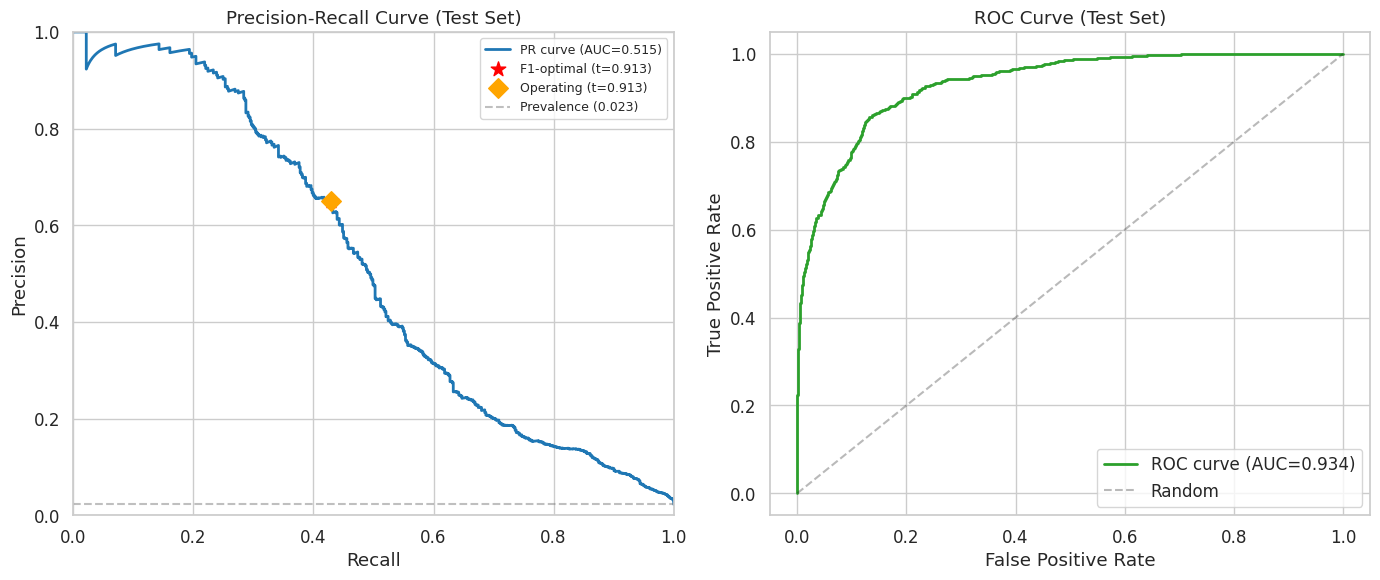

✓ Saved: results/wb04/pr_roc_curves.png


In [9]:
# ════════════════════════════════════════════════════════════════
# 1.2b  Plot PR and ROC curves
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PR curve
ax = axes[0]
ax.plot(recall, precision, color="tab:blue", linewidth=2,
        label=f"PR curve (AUC={pr_auc:.3f})")
ax.scatter(f1_opt_recall, f1_opt_precision, color="red", s=120, zorder=5,
           marker="*", label=f"F1-optimal (t={f1_opt_threshold:.3f})")
ax.scatter(op_rec, op_prec, color="orange", s=100, zorder=5,
           marker="D", label=f"Operating (t={op_threshold:.3f})")
ax.axhline(y=test_labels.mean(), color="grey", linestyle="--",
           alpha=0.5, label=f"Prevalence ({test_labels.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (Test Set)")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# ROC curve
ax = axes[1]
ax.plot(fpr, tpr, color="tab:green", linewidth=2,
        label=f"ROC curve (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (Test Set)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(WB04_DIR / "pr_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {WB04_DIR / 'pr_roc_curves.png'}")

## 1.3 Stratified Explanation Sample Selection

In [10]:
# ════════════════════════════════════════════════════════════════
# 1.3  Stratified explanation sample
# ════════════════════════════════════════════════════════════════
threshold = op_threshold
preds = (test_probs >= threshold).astype(int)

# Classify into quadrants
quadrants = []
for i in range(len(test_labels)):
    y, yhat, p = test_labels[i], preds[i], test_probs[i]
    if y == 1 and yhat == 1:
        # TP: split into confident vs borderline
        if p >= threshold + 0.03:
            quadrants.append("TP_confident")
        else:
            quadrants.append("TP_borderline")
    elif y == 0 and yhat == 1:
        quadrants.append("FP")
    elif y == 1 and yhat == 0:
        quadrants.append("FN")
    else:
        # TN: split into random vs near-threshold
        if p >= threshold - 0.15:
            quadrants.append("TN_near")
        else:
            quadrants.append("TN_random")
quadrants = np.array(quadrants)

# Size buckets
size_buckets = np.where(test_n_nodes == 2, "2-node",
               np.where(test_n_nodes == 3, "3-node", "4+-node"))

# Target counts per quadrant
TARGETS = {
    "TP_confident":  40,
    "TP_borderline": 20,
    "FP":            40,
    "FN":            40,
    "TN_random":     30,
    "TN_near":       30,
}

# Available counts
print("Available subgraphs per quadrant × size:")
for q in TARGETS:
    mask = quadrants == q
    print(f"  {q:16s}: {mask.sum():5d} total  |  "
          f"2-node: {((quadrants==q) & (size_buckets=='2-node')).sum():4d}  "
          f"3-node: {((quadrants==q) & (size_buckets=='3-node')).sum():4d}  "
          f"4+-node: {((quadrants==q) & (size_buckets=='4+-node')).sum():4d}")

# Stratified sampling
rng = np.random.RandomState(RNG_SEED)
sample_indices = []
sample_meta = []

for q, target in TARGETS.items():
    q_mask = quadrants == q
    q_indices = np.where(q_mask)[0]

    if len(q_indices) == 0:
        print(f"  ⚠️ No samples in {q}")
        continue

    # Attempt proportional sampling across size buckets
    sizes_in_q = size_buckets[q_indices]
    unique_sizes = np.unique(sizes_in_q)

    per_size = max(target // len(unique_sizes), 1)
    selected = []

    for sz in unique_sizes:
        sz_mask = sizes_in_q == sz
        sz_indices = q_indices[sz_mask]
        n_take = min(per_size, len(sz_indices))
        chosen = rng.choice(sz_indices, size=n_take, replace=False)
        selected.extend(chosen.tolist())

    # Fill remainder if needed
    remaining = target - len(selected)
    if remaining > 0:
        leftover = list(set(q_indices.tolist()) - set(selected))
        if leftover:
            extra = rng.choice(leftover, size=min(remaining, len(leftover)),
                               replace=False)
            selected.extend(extra.tolist())

    # Truncate if oversampled
    selected = selected[:target]
    sample_indices.extend(selected)

    for idx in selected:
        sample_meta.append({
            "test_idx": int(idx),
            "ccId": int(test_ccids[idx]),
            "quadrant": q,
            "size_bucket": size_buckets[idx],
            "n_nodes": int(test_n_nodes[idx]),
            "n_edges": int(test_n_edges[idx]),
            "y_true": int(test_labels[idx]),
            "prob": float(test_probs[idx]),
            "y_pred": int(preds[idx]),
        })

sample_indices = np.array(sample_indices)
print(f"\n✓ Explanation sample: {len(sample_indices)} subgraphs")

# Summary
sample_df = pd.DataFrame(sample_meta)
print("\nSample distribution:")
print(sample_df.groupby(["quadrant", "size_bucket"]).size().unstack(fill_value=0))

Available subgraphs per quadrant × size:
  TP_confident    :   211 total  |  2-node:  107  3-node:   49  4+-node:   55
  TP_borderline   :    26 total  |  2-node:    9  3-node:    5  4+-node:   12
  FP              :   127 total  |  2-node:   66  3-node:   21  4+-node:   40
  FN              :   316 total  |  2-node:  120  3-node:   58  4+-node:  138
  TN_random       : 23176 total  |  2-node: 11354  3-node: 4125  4+-node: 7697
  TN_near         :   506 total  |  2-node:  247  3-node:   94  4+-node:  165

✓ Explanation sample: 200 subgraphs

Sample distribution:
size_bucket    2-node  3-node  4+-node
quadrant                              
FN                 13      13       14
FP                 14      13       13
TN_near            10      10       10
TN_random          10      10       10
TP_borderline       8       5        7
TP_confident       14      13       13


In [11]:
# ════════════════════════════════════════════════════════════════
# 1.3b  Save explanation sample
# ════════════════════════════════════════════════════════════════
sample_df.to_csv(WB04_DIR / "explanation_sample.csv", index=False)

# Also save as JSON for programmatic use
with open(WB04_DIR / "explanation_sample.json", "w") as f:
    json.dump(sample_meta, f, indent=2)

# Create a quick lookup: ccId → sample metadata
sample_ccids = sample_df["ccId"].values
sample_lookup = {int(row["ccId"]): row for _, row in sample_df.iterrows()}

print(f"✓ Saved explanation sample ({len(sample_df)} subgraphs) to:")
print(f"  {WB04_DIR / 'explanation_sample.csv'}")
print(f"  {WB04_DIR / 'explanation_sample.json'}")

✓ Saved explanation sample (200 subgraphs) to:
  results/wb04/explanation_sample.csv
  results/wb04/explanation_sample.json


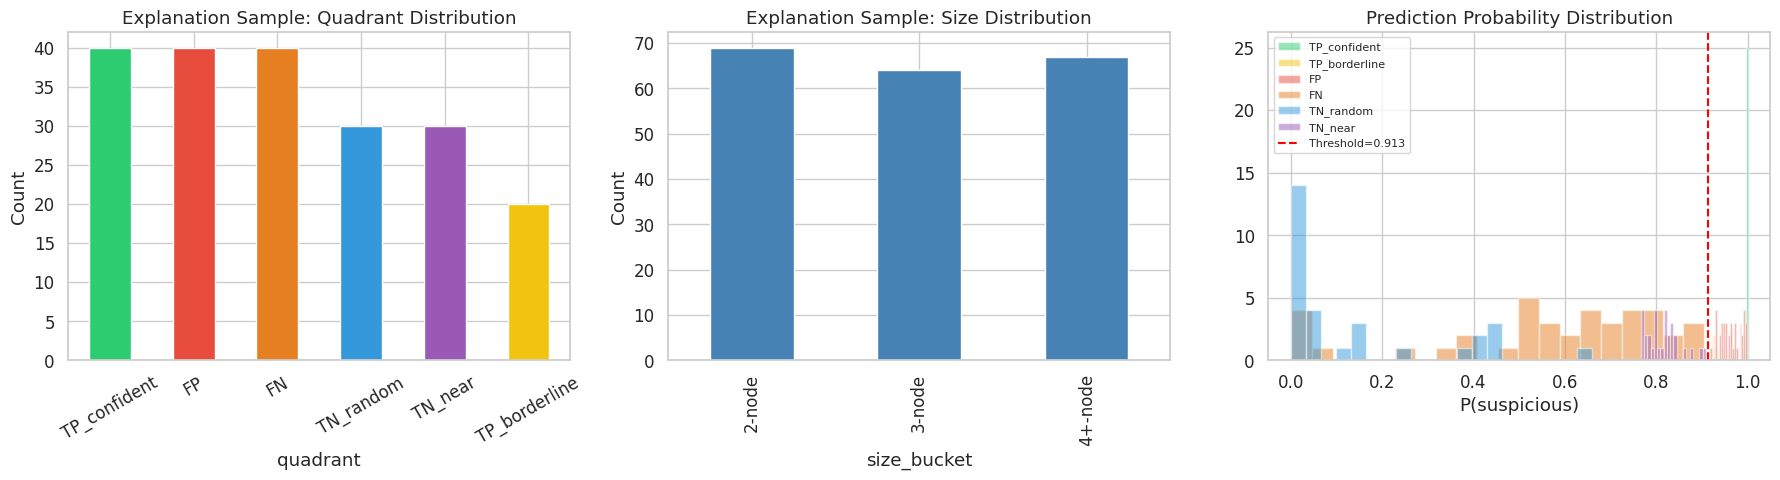

✓ Saved: results/wb04/explanation_sample_distribution.png


In [12]:
# ════════════════════════════════════════════════════════════════
# 1.4  Visualise explanation sample
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quadrant distribution
ax = axes[0]
q_counts = sample_df["quadrant"].value_counts()
colors = {"TP_confident": "#2ecc71", "TP_borderline": "#f1c40f",
          "FP": "#e74c3c", "FN": "#e67e22", "TN_random": "#3498db",
          "TN_near": "#9b59b6"}
q_counts.plot.bar(ax=ax, color=[colors.get(q, "gray") for q in q_counts.index])
ax.set_title("Explanation Sample: Quadrant Distribution")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=30)

# Size distribution
ax = axes[1]
sample_df["size_bucket"].value_counts().sort_index().plot.bar(
    ax=ax, color="steelblue")
ax.set_title("Explanation Sample: Size Distribution")
ax.set_ylabel("Count")

# Probability distribution by quadrant
ax = axes[2]
for q in sample_df["quadrant"].unique():
    subset = sample_df[sample_df["quadrant"] == q]["prob"]
    ax.hist(subset, bins=20, alpha=0.5, label=q, color=colors.get(q, "gray"))
ax.axvline(x=threshold, color="red", linestyle="--", label=f"Threshold={threshold:.3f}")
ax.set_title("Prediction Probability Distribution")
ax.set_xlabel("P(suspicious)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(WB04_DIR / "explanation_sample_distribution.png", dpi=150,
            bbox_inches="tight")
plt.show()
print(f"✓ Saved: {WB04_DIR / 'explanation_sample_distribution.png'}")

### Tier 0 Summary

# Tier 1 - wb05: Feature Attribution Methods

## 2.1 Method A: Integrated Gradients

In [13]:
# ════════════════════════════════════════════════════════════════
# 2.1  Integrated Gradients - Setup
# ════════════════════════════════════════════════════════════════
def model_forward_for_captum(x, edge_index, batch):
    """Captum-compatible forward function returning class-1 logit."""
    logits = model(x, edge_index, batch)
    return logits[:, 1]  # suspicious class logit


def compute_ig_for_subgraph(data, n_steps=50):
    """Compute Integrated Gradients attributions for a single subgraph.

    Returns:
        node_attr: [n_nodes, 43] attribution per node × feature
        subgraph_attr: [43] mean |attribution| across nodes
    """
    data = data.to(DEVICE)
    x = data.x.clone().requires_grad_(True)
    edge_index = data.edge_index
    batch = torch.zeros(x.size(0), dtype=torch.long, device=DEVICE)

    # Baseline: zero vector
    baseline = torch.zeros_like(x)

    # Integrated Gradients via Captum
    ig = IntegratedGradients(model_forward_for_captum)
    attr = ig.attribute(
        x,
        baselines=baseline,
        additional_forward_args=(edge_index, batch),
        n_steps=n_steps,
        internal_batch_size=1,
    )

    node_attr = attr.detach().cpu().numpy()
    subgraph_attr = np.abs(node_attr).mean(axis=0)  # [43]
    return node_attr, subgraph_attr


# Quick test on first sample
test_data = test_ds[int(sample_indices[0])]
node_attr, sg_attr = compute_ig_for_subgraph(test_data)
print(f"IG test - nodes: {test_data.x.shape[0]}, features: {test_data.x.shape[1]}")
print(f"Node attributions shape: {node_attr.shape}")
print(f"Subgraph attribution shape: {sg_attr.shape}")
print(f"Top-5 features: {np.argsort(sg_attr)[::-1][:5]}")

IG test — nodes: 2, features: 43
Node attributions shape: (2, 43)
Subgraph attribution shape: (43,)
Top-5 features: [19 29 27 31 23]


In [14]:
# ════════════════════════════════════════════════════════════════
# 2.1b  Run IG on full explanation sample
# ════════════════════════════════════════════════════════════════
print(f"Running Integrated Gradients on {len(sample_indices)} subgraphs...")
model.eval()

ig_results = {}
ig_subgraph_attrs = []  # [N_sample, 43]
ig_node_attrs = {}      # ccId → node_attr array

t0 = time.time()
for i, idx in enumerate(sample_indices):
    data = test_ds[int(idx)]
    ccid = int(test_ccids[idx])

    try:
        node_attr, sg_attr = compute_ig_for_subgraph(data, n_steps=50)
        ig_results[ccid] = {
            "node_attr": node_attr,
            "subgraph_attr": sg_attr,
        }
        ig_subgraph_attrs.append(sg_attr)
        ig_node_attrs[ccid] = node_attr
    except Exception as e:
        print(f"  ⚠️ IG failed for ccId={ccid}: {e}")
        ig_subgraph_attrs.append(np.zeros(IN_DIM))

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f"  [{i+1}/{len(sample_indices)}] {elapsed:.1f}s "
              f"({elapsed/(i+1):.2f}s/sample)")

ig_subgraph_attrs = np.array(ig_subgraph_attrs)
elapsed = time.time() - t0
print(f"\n✓ IG completed in {elapsed:.1f}s ({elapsed/len(sample_indices):.2f}s/sample)")
print(f"Attribution matrix: {ig_subgraph_attrs.shape}")

Running Integrated Gradients on 200 subgraphs...
  [50/200] 10.1s (0.20s/sample)
  [100/200] 19.9s (0.20s/sample)
  [150/200] 29.4s (0.20s/sample)
  [200/200] 38.9s (0.19s/sample)

✓ IG completed in 38.9s (0.19s/sample)
Attribution matrix: (200, 43)


## 2.2 Method B: Graph-Aware Shapley Value Approximation (GraphSVX-style)

In [15]:
# ════════════════════════════════════════════════════════════════
# 2.2  GraphSVX-style Shapley approximation
# ════════════════════════════════════════════════════════════════
def compute_shapley_for_subgraph(data, n_samples=200, baseline_value=0.0):
    """Monte Carlo Shapley value approximation for graph classification.

    For each feature, estimates its marginal contribution by sampling random
    coalitions (subsets of features) and measuring the change in prediction
    when the feature is included vs excluded.

    Parameters:
        data: PyG Data object
        n_samples: number of MC samples per feature
        baseline_value: value to use when a feature is "masked out"

    Returns:
        shapley_values: [43] Shapley value per feature
    """
    data = data.to(DEVICE)
    n_features = data.x.shape[1]
    batch = torch.zeros(data.x.shape[0], dtype=torch.long, device=DEVICE)

    # Get baseline prediction (all features masked)
    x_baseline = torch.full_like(data.x, baseline_value)
    with torch.no_grad():
        logit_baseline = model(x_baseline, data.edge_index, batch)[:, 1].item()

    # Get full prediction
    with torch.no_grad():
        logit_full = model(data.x, data.edge_index, batch)[:, 1].item()

    shapley_values = np.zeros(n_features)

    for feat_idx in range(n_features):
        marginal_contributions = []

        for _ in range(n_samples):
            # Random coalition (subset of features, excluding feat_idx)
            other_features = list(range(n_features))
            other_features.remove(feat_idx)
            coalition_size = np.random.randint(0, n_features)
            coalition = set(np.random.choice(
                other_features,
                size=min(coalition_size, len(other_features)),
                replace=False
            ))

            # Evaluate with coalition (without feat_idx)
            x_without = torch.full_like(data.x, baseline_value)
            for f in coalition:
                x_without[:, f] = data.x[:, f]

            # Evaluate with coalition + feat_idx
            x_with = x_without.clone()
            x_with[:, feat_idx] = data.x[:, feat_idx]

            with torch.no_grad():
                v_without = model(x_without, data.edge_index, batch)[:, 1].item()
                v_with = model(x_with, data.edge_index, batch)[:, 1].item()

            marginal_contributions.append(v_with - v_without)

        shapley_values[feat_idx] = np.mean(marginal_contributions)

    return shapley_values


# Test on first sample
test_data = test_ds[int(sample_indices[0])]
sv = compute_shapley_for_subgraph(test_data, n_samples=100)
print(f"Shapley test - shape: {sv.shape}")
print(f"Top-5 features (by |Shapley|): {np.argsort(np.abs(sv))[::-1][:5]}")
print(f"Sum of Shapley values: {sv.sum():.4f}")

Shapley test — shape: (43,)
Top-5 features (by |Shapley|): [19 29 27 24 31]
Sum of Shapley values: 2.5311


In [16]:
# ════════════════════════════════════════════════════════════════
# 2.2b  Run Shapley on explanation sample
# ════════════════════════════════════════════════════════════════
# Note: Shapley is slower than IG. Reduce n_samples if needed.
N_SHAPLEY_SAMPLES = 150  # MC samples per feature

print(f"Running Shapley approximation on {len(sample_indices)} subgraphs "
      f"({N_SHAPLEY_SAMPLES} MC samples/feature)...")

shapley_results = {}
shapley_subgraph_attrs = []

t0 = time.time()
for i, idx in enumerate(sample_indices):
    data = test_ds[int(idx)]
    ccid = int(test_ccids[idx])

    try:
        sv = compute_shapley_for_subgraph(data, n_samples=N_SHAPLEY_SAMPLES)
        shapley_results[ccid] = sv
        shapley_subgraph_attrs.append(np.abs(sv))  # |Shapley| for ranking
    except Exception as e:
        print(f"  ⚠️ Shapley failed for ccId={ccid}: {e}")
        shapley_subgraph_attrs.append(np.zeros(IN_DIM))

    if (i + 1) % 20 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (len(sample_indices) - i - 1)
        print(f"  [{i+1}/{len(sample_indices)}] {elapsed:.0f}s elapsed, "
              f"~{eta:.0f}s remaining")

shapley_subgraph_attrs = np.array(shapley_subgraph_attrs)
elapsed = time.time() - t0
print(f"\n✓ Shapley completed in {elapsed:.1f}s ({elapsed/len(sample_indices):.2f}s/sample)")

Running Shapley approximation on 200 subgraphs (150 MC samples/feature)...
  [20/200] 507s elapsed, ~4566s remaining
  [40/200] 1017s elapsed, ~4068s remaining
  [60/200] 1525s elapsed, ~3558s remaining
  [80/200] 2032s elapsed, ~3047s remaining
  [100/200] 2542s elapsed, ~2542s remaining
  [120/200] 3048s elapsed, ~2032s remaining
  [140/200] 3558s elapsed, ~1525s remaining
  [160/200] 4067s elapsed, ~1017s remaining
  [180/200] 4576s elapsed, ~508s remaining
  [200/200] 5089s elapsed, ~0s remaining

✓ Shapley completed in 5088.9s (25.44s/sample)


## 2.3 Feature Attribution Analysis
### Evaluation metrics:

In [17]:
# ════════════════════════════════════════════════════════════════
# 2.3a  Global feature importance rankings
# ════════════════════════════════════════════════════════════════
# Mean |attribution| across all explanation samples
ig_global  = ig_subgraph_attrs.mean(axis=0)
sv_global  = shapley_subgraph_attrs.mean(axis=0)

ig_ranking  = np.argsort(ig_global)[::-1]
sv_ranking  = np.argsort(sv_global)[::-1]

print("Global Feature Importance Rankings")
print("=" * 65)
print(f"{'Rank':<6} {'IG Feature':<15} {'IG Score':<12} {'SV Feature':<15} {'SV Score':<12}")
print("-" * 65)
for r in range(min(15, IN_DIM)):
    print(f"{r+1:<6} Feature {ig_ranking[r]:<6} {ig_global[ig_ranking[r]]:<12.4f} "
          f"Feature {sv_ranking[r]:<6} {sv_global[sv_ranking[r]]:<12.4f}")

# Top-10 agreement
ig_top10 = set(ig_ranking[:10])
sv_top10 = set(sv_ranking[:10])
jaccard_top10 = len(ig_top10 & sv_top10) / len(ig_top10 | sv_top10)
print(f"\nTop-10 Jaccard (IG vs Shapley): {jaccard_top10:.3f}")
print(f"Overlap: {ig_top10 & sv_top10}")

Global Feature Importance Rankings
Rank   IG Feature      IG Score     SV Feature      SV Score    
-----------------------------------------------------------------
1      Feature 19     1.7044       Feature 19     3.6053      
2      Feature 31     0.7212       Feature 31     1.6342      
3      Feature 29     0.6639       Feature 29     1.4304      
4      Feature 23     0.6322       Feature 17     1.2788      
5      Feature 0      0.5504       Feature 35     1.2645      
6      Feature 35     0.5102       Feature 0      0.9202      
7      Feature 17     0.5031       Feature 1      0.6925      
8      Feature 27     0.4460       Feature 27     0.6697      
9      Feature 1      0.2887       Feature 23     0.6492      
10     Feature 4      0.2132       Feature 18     0.6320      
11     Feature 33     0.2130       Feature 4      0.5126      
12     Feature 20     0.2122       Feature 3      0.4800      
13     Feature 3      0.1812       Feature 24     0.4757      
14     Feature 

In [18]:
# ════════════════════════════════════════════════════════════════
# 2.3b  Spearman rank correlation (IG vs Shapley)
# ════════════════════════════════════════════════════════════════
# Per-subgraph rank correlation
per_sample_correlations = []
for i in range(len(sample_indices)):
    ig_rank = sp_stats.rankdata(-ig_subgraph_attrs[i])
    sv_rank = sp_stats.rankdata(-shapley_subgraph_attrs[i])
    rho, pval = sp_stats.spearmanr(ig_rank, sv_rank)
    per_sample_correlations.append(rho)

per_sample_correlations = np.array(per_sample_correlations)

# Global rank correlation
rho_global, p_global = sp_stats.spearmanr(
    sp_stats.rankdata(-ig_global),
    sp_stats.rankdata(-sv_global)
)

print("IG vs Shapley Agreement")
print("=" * 50)
print(f"Global Spearman ρ:     {rho_global:.4f} (p={p_global:.2e})")
print(f"Per-sample Spearman ρ: {np.nanmean(per_sample_correlations):.4f} "
      f"± {np.nanstd(per_sample_correlations):.4f}")
print(f"  Median: {np.nanmedian(per_sample_correlations):.4f}")
print(f"  Range:  [{np.nanmin(per_sample_correlations):.4f}, "
      f"{np.nanmax(per_sample_correlations):.4f}]")

IG vs Shapley Agreement
Global Spearman ρ:     0.9505 (p=2.03e-22)
Per-sample Spearman ρ: 0.9335 ± 0.0555
  Median: 0.9455
  Range:  [0.6437, 0.9963]


In [19]:
# ════════════════════════════════════════════════════════════════
# 2.3c  Class-discriminative features
# ════════════════════════════════════════════════════════════════
# Split attributions by true class
suspicious_mask = sample_df["y_true"].values == 1
licit_mask = sample_df["y_true"].values == 0

ig_suspicious = ig_subgraph_attrs[suspicious_mask].mean(axis=0)
ig_licit = ig_subgraph_attrs[licit_mask].mean(axis=0)
ig_diff = ig_suspicious - ig_licit

sv_suspicious = shapley_subgraph_attrs[suspicious_mask].mean(axis=0)
sv_licit = shapley_subgraph_attrs[licit_mask].mean(axis=0)
sv_diff = sv_suspicious - sv_licit

# Top class-discriminative features (by IG difference)
disc_ranking = np.argsort(np.abs(ig_diff))[::-1]
print("Top Class-Discriminative Features (IG)")
print("=" * 70)
print(f"{'Rank':<6} {'Feature':<10} {'Susp Mean':<12} {'Licit Mean':<12} {'Diff':<10}")
print("-" * 70)
for r in range(min(15, IN_DIM)):
    f = disc_ranking[r]
    print(f"{r+1:<6} F{f:<8} {ig_suspicious[f]:<12.4f} {ig_licit[f]:<12.4f} "
          f"{ig_diff[f]:<+10.4f}")

Top Class-Discriminative Features (IG)
Rank   Feature    Susp Mean    Licit Mean   Diff      
----------------------------------------------------------------------
1      F19       1.5299       1.8789       -0.3490   
2      F23       0.5652       0.6992       -0.1339   
3      F27       0.5119       0.3801       +0.1318   
4      F4        0.1612       0.2651       -0.1040   
5      F17       0.4630       0.5431       -0.0802   
6      F29       0.6248       0.7029       -0.0781   
7      F31       0.6833       0.7591       -0.0758   
8      F3        0.1446       0.2178       -0.0732   
9      F35       0.4737       0.5468       -0.0731   
10     F10       0.1076       0.1741       -0.0666   
11     F20       0.1800       0.2444       -0.0644   
12     F9        0.1470       0.2016       -0.0546   
13     F7        0.1295       0.1832       -0.0537   
14     F22       0.0830       0.1315       -0.0485   
15     F18       0.1518       0.1974       -0.0456   


In [20]:
# ════════════════════════════════════════════════════════════════
# 2.3d  Feature ranking stability (Jaccard across TP subgraphs)
# ════════════════════════════════════════════════════════════════
tp_mask = sample_df["quadrant"].str.startswith("TP").values
tp_attrs = ig_subgraph_attrs[tp_mask]

K = 5  # top-K features
tp_top_k_sets = [set(np.argsort(a)[::-1][:K]) for a in tp_attrs]

# Pairwise Jaccard
jaccards = []
for i in range(len(tp_top_k_sets)):
    for j in range(i + 1, len(tp_top_k_sets)):
        s1, s2 = tp_top_k_sets[i], tp_top_k_sets[j]
        jacc = len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0
        jaccards.append(jacc)

jaccards = np.array(jaccards)
print(f"Feature Ranking Stability (Top-{K}, TP subgraphs)")
print(f"  Mean pairwise Jaccard: {jaccards.mean():.4f}")
print(f"  Std:                   {jaccards.std():.4f}")
print(f"  Range:                 [{jaccards.min():.4f}, {jaccards.max():.4f}]")

# Most frequently top-K feature across TPs
from collections import Counter
all_top_k = [f for s in tp_top_k_sets for f in s]
top_k_freq = Counter(all_top_k).most_common(10)
print(f"\nMost frequent top-{K} features across TPs:")
for feat, count in top_k_freq:
    print(f"  Feature {feat}: appears in {count}/{len(tp_top_k_sets)} "
          f"({100*count/len(tp_top_k_sets):.0f}%) of TP subgraphs")

Feature Ranking Stability (Top-5, TP subgraphs)
  Mean pairwise Jaccard: 0.4788
  Std:                   0.1919
  Range:                 [0.1111, 1.0000]

Most frequent top-5 features across TPs:
  Feature 19: appears in 60/60 (100%) of TP subgraphs
  Feature 31: appears in 44/60 (73%) of TP subgraphs
  Feature 0: appears in 44/60 (73%) of TP subgraphs
  Feature 23: appears in 34/60 (57%) of TP subgraphs
  Feature 29: appears in 34/60 (57%) of TP subgraphs
  Feature 27: appears in 31/60 (52%) of TP subgraphs
  Feature 35: appears in 17/60 (28%) of TP subgraphs
  Feature 17: appears in 15/60 (25%) of TP subgraphs
  Feature 1: appears in 8/60 (13%) of TP subgraphs
  Feature 3: appears in 6/60 (10%) of TP subgraphs


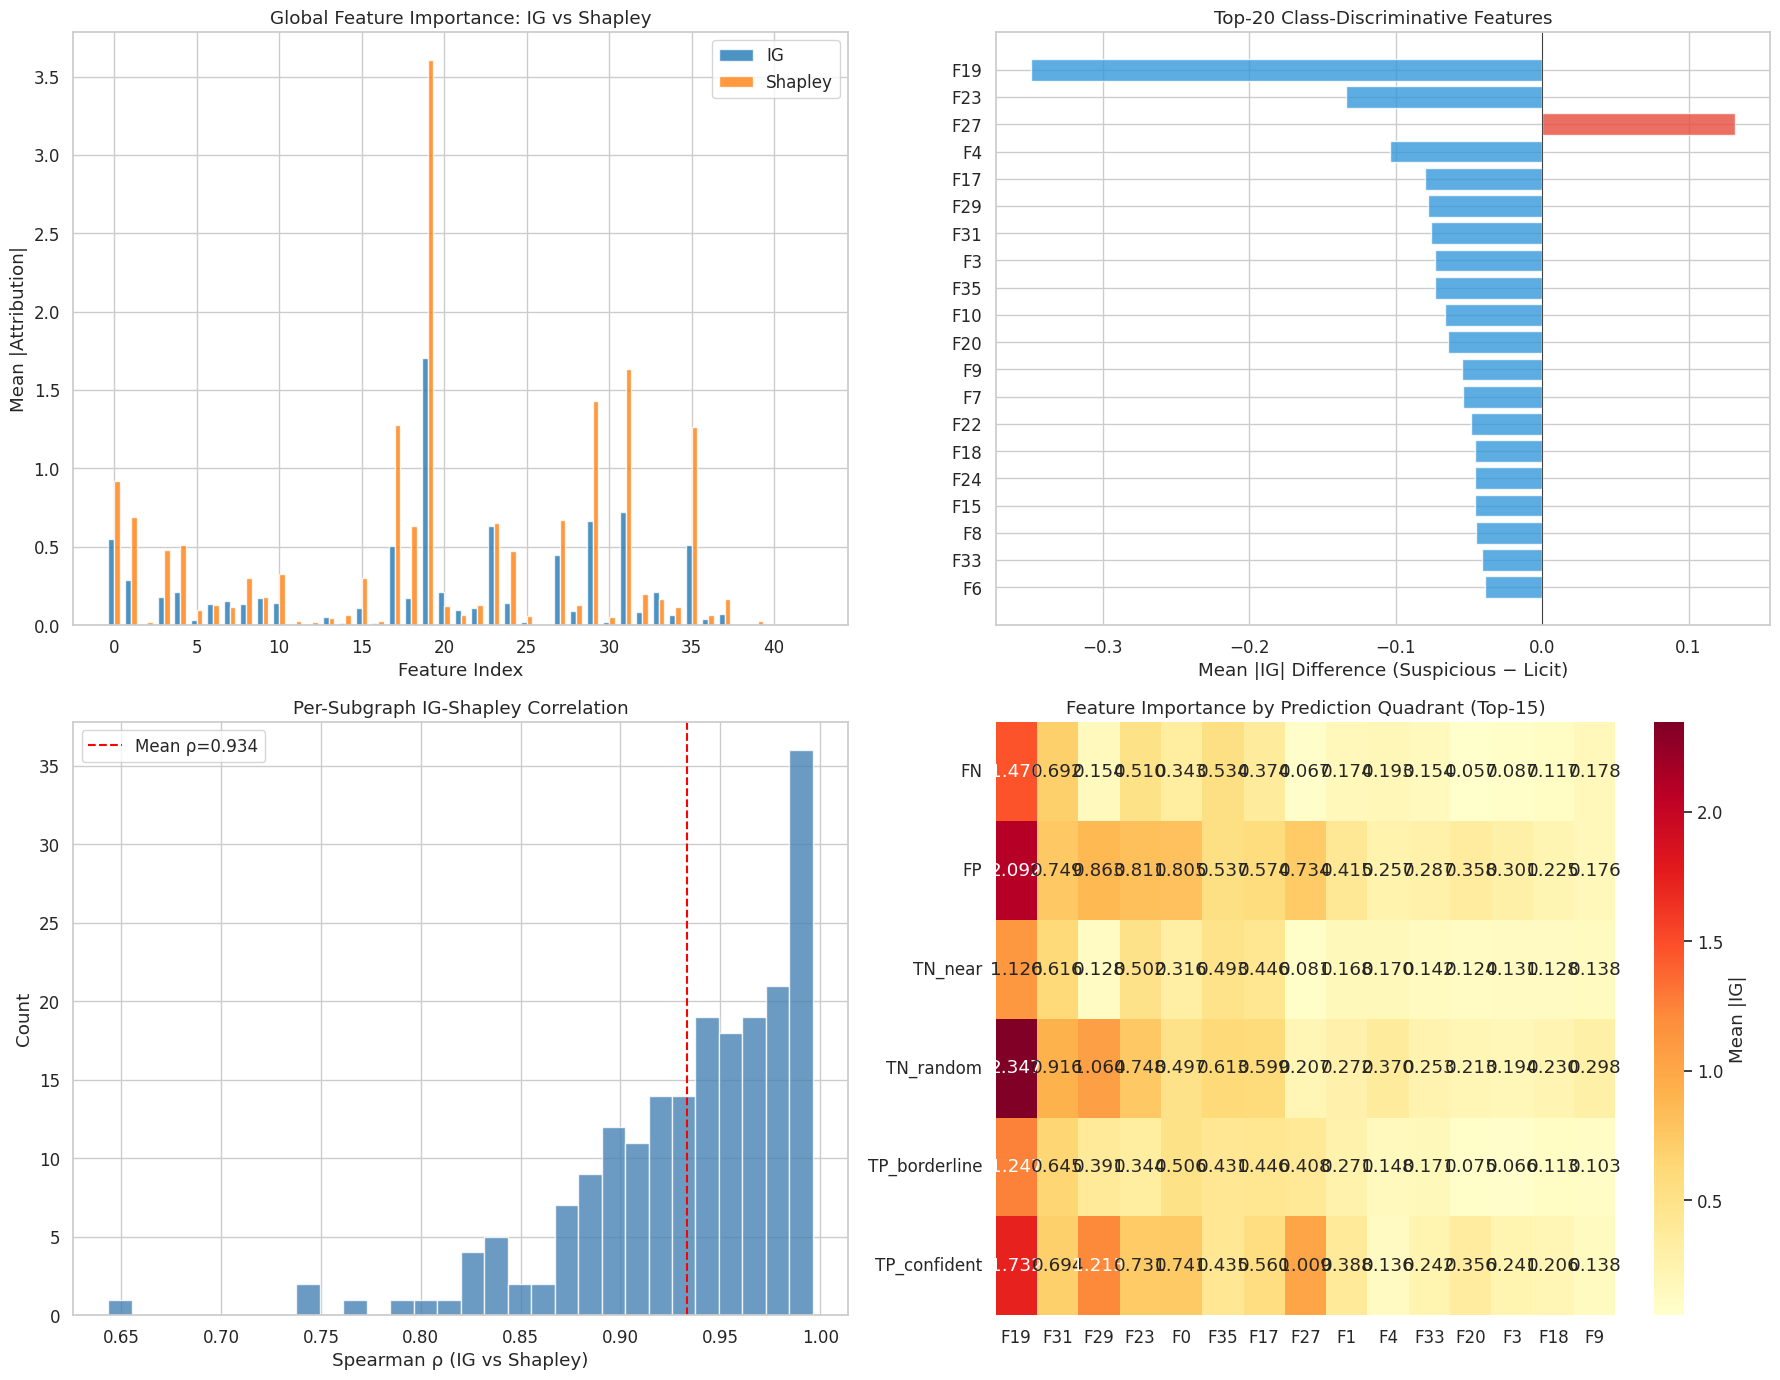

✓ Saved: results/wb05/feature_attribution_analysis.png


In [21]:
# ════════════════════════════════════════════════════════════════
# 2.3e  Feature importance visualisation
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# (a) Global feature importance - IG vs Shapley
ax = axes[0, 0]
x_pos = np.arange(IN_DIM)
width = 0.35
ax.bar(x_pos - width/2, ig_global, width, label="IG", alpha=0.8, color="tab:blue")
ax.bar(x_pos + width/2, sv_global, width, label="Shapley", alpha=0.8, color="tab:orange")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Mean |Attribution|")
ax.set_title("Global Feature Importance: IG vs Shapley")
ax.legend()
ax.set_xticks(range(0, IN_DIM, 5))

# (b) Class-discriminative features (IG)
ax = axes[0, 1]
sorted_disc = disc_ranking[:20]
colors = ["#e74c3c" if ig_diff[f] > 0 else "#3498db" for f in sorted_disc]
ax.barh(range(len(sorted_disc)), [ig_diff[f] for f in sorted_disc],
        color=colors, alpha=0.8)
ax.set_yticks(range(len(sorted_disc)))
ax.set_yticklabels([f"F{f}" for f in sorted_disc])
ax.set_xlabel("Mean |IG| Difference (Suspicious − Licit)")
ax.set_title("Top-20 Class-Discriminative Features")
ax.invert_yaxis()
ax.axvline(x=0, color="black", linewidth=0.5)

# (c) Per-sample IG vs Shapley correlation
ax = axes[1, 0]
ax.hist(per_sample_correlations, bins=30, color="steelblue", alpha=0.8,
        edgecolor="white")
ax.axvline(x=np.nanmean(per_sample_correlations), color="red", linestyle="--",
           label=f"Mean ρ={np.nanmean(per_sample_correlations):.3f}")
ax.set_xlabel("Spearman ρ (IG vs Shapley)")
ax.set_ylabel("Count")
ax.set_title("Per-Subgraph IG-Shapley Correlation")
ax.legend()

# (d) Feature importance heatmap by quadrant
ax = axes[1, 1]
# Compute mean |IG| per quadrant for top-15 features
top15 = ig_ranking[:15]
quadrant_names = sample_df["quadrant"].unique()
heatmap_data = []
for q in sorted(quadrant_names):
    q_mask = sample_df["quadrant"].values == q
    q_attrs = ig_subgraph_attrs[q_mask][:, top15].mean(axis=0)
    heatmap_data.append(q_attrs)
heatmap_data = np.array(heatmap_data)
sns.heatmap(heatmap_data, ax=ax, xticklabels=[f"F{f}" for f in top15],
            yticklabels=sorted(quadrant_names), cmap="YlOrRd",
            annot=True, fmt=".3f", cbar_kws={"label": "Mean |IG|"})
ax.set_title("Feature Importance by Prediction Quadrant (Top-15)")

plt.tight_layout()
plt.savefig(WB05_DIR / "feature_attribution_analysis.png", dpi=150,
            bbox_inches="tight")
plt.show()
print(f"✓ Saved: {WB05_DIR / 'feature_attribution_analysis.png'}")

Excluding 1 invalid/constant features: [42]
Anonymised Feature Clusters (from IG attribution patterns)
  Cluster 1: Features [0, 1, 17, 19, 21, 25, 27, 29, 31, 33, 35, 37] (mean importance: 0.4821)
  Cluster 2: Features [3, 4, 5, 7, 9, 15, 23, 30, 39, 41] (mean importance: 0.1538)
  Cluster 3: Features [2, 11, 12] (mean importance: 0.0071)
  Cluster 4: Features [6, 13, 20, 22, 24, 26, 28, 32, 34, 36] (mean importance: 0.0934)
  Cluster 5: Features [8, 10, 14, 16, 18, 38, 40] (mean importance: 0.0686)


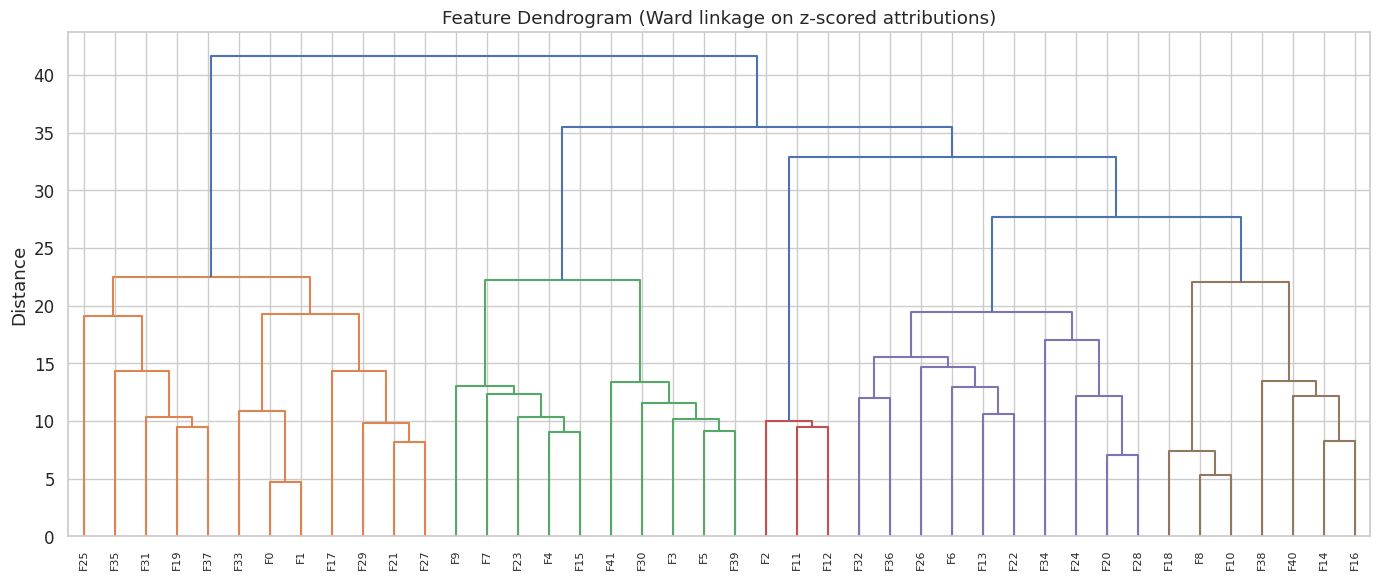

Saved: results/wb05/feature_dendrogram.png
Saved attribution arrays to results/wb05


In [24]:
# 2.3f  Feature clustering (anonymised feature characterisation)
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Cluster features by their attribution pattern across subgraphs
# Transpose: features x subgraphs -> cluster features that behave similarly
attr_matrix = np.asarray(ig_subgraph_attrs.T, dtype=float)  # [43, N_samples]

# Guard against non-finite and constant feature profiles
finite_mask = np.isfinite(attr_matrix).all(axis=1)
std_mask = attr_matrix.std(axis=1) > 1e-12
valid_mask = finite_mask & std_mask
valid_feature_ids = np.where(valid_mask)[0]

if len(valid_feature_ids) < 2:
    raise ValueError(
        f"Need at least 2 valid features for clustering, got {len(valid_feature_ids)}. "
        "Check ig_subgraph_attrs for NaN/inf or all-constant rows."
    )

if (~valid_mask).any():
    bad_ids = np.where(~valid_mask)[0].tolist()
    print(f"Excluding {len(bad_ids)} invalid/constant features: {bad_ids}")

# Ward requires Euclidean distances; z-scoring rows makes it correlation-like
X = attr_matrix[valid_mask]
X = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

Z = linkage(X, method="ward", metric="euclidean")

# Cut at k=5 clusters
N_CLUSTERS = 5
n_clusters_eff = min(N_CLUSTERS, len(valid_feature_ids))
clusters_valid = fcluster(Z, t=n_clusters_eff, criterion="maxclust")

# Fill full feature vector; excluded features get -1
clusters = np.full(IN_DIM, -1, dtype=int)
clusters[valid_feature_ids] = clusters_valid

print("Anonymised Feature Clusters (from IG attribution patterns)")
print("=" * 60)
for c in range(1, n_clusters_eff + 1):
    members = np.where(clusters == c)[0]
    if len(members) == 0:
        continue
    mean_importance = ig_global[members].mean()
    print(f"  Cluster {c}: Features {list(members)} (mean importance: {mean_importance:.4f})")

# Dendrogram
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
dendrogram(
    Z,
    labels=[f"F{i}" for i in valid_feature_ids],
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=Z[-(n_clusters_eff - 1), 2] if n_clusters_eff > 1 else 0.0,
)
ax.set_title("Feature Dendrogram (Ward linkage on z-scored attributions)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(WB05_DIR / "feature_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {WB05_DIR / 'feature_dendrogram.png'}")

# Save IG and Shapley results
np.save(WB05_DIR / "ig_subgraph_attributions.npy", ig_subgraph_attrs)
np.save(WB05_DIR / "shapley_subgraph_attributions.npy", shapley_subgraph_attrs)
np.save(WB05_DIR / "feature_clusters.npy", clusters)
print(f"Saved attribution arrays to {WB05_DIR}")


### Tier 1 Summary

# Tier 2 - wb06: Graph-Native Structural Explanations

## 3.1 Method C: GNNExplainer

In [13]:
# ════════════════════════════════════════════════════════════════
# 3.1  GNNExplainer - Setup
# ════════════════════════════════════════════════════════════════
# Define a wrapper model that takes (x, edge_index, batch) and returns raw logits
# This is needed because PyG's Explainer API expects specific signatures.

class ModelWrapper(nn.Module):
    """Thin wrapper to make our model compatible with PyG Explainer API."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, batch=None):
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        return self.model(x, edge_index, batch)


wrapped_model = ModelWrapper(model)
wrapped_model.eval()

# Configure GNNExplainer
gnn_explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=200, lr=0.01),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="binary_classification",
        task_level="graph",
        return_type="raw",
    ),
)

print("✓ GNNExplainer configured")
print(f"  Epochs: 200, lr: 0.01")
print(f"  Mask types: node_attributes + edge_object")

✓ GNNExplainer configured
  Epochs: 200, lr: 0.01
  Mask types: node_attributes + edge_object


In [14]:
# Recover global node feature matrix
X = np.load(DATA_DIR / "arrays" / "node_features.npy")
print("X restored:", X.shape)  # expected: (444521, 43)


X restored: (444521, 43)


In [15]:
# ════════════════════════════════════════════════════════════════
# 3.1b  Run GNNExplainer on explanation sample
# ════════════════════════════════════════════════════════════════
print(f"Running GNNExplainer on {len(sample_indices)} subgraphs...")

gnnexp_results = {}
t0 = time.time()

for i, idx in enumerate(sample_indices):
    data = test_ds[int(idx)].to(DEVICE)
    ccid = int(test_ccids[idx])
    target = torch.tensor([int(test_labels[idx])], device=DEVICE)

    try:
        explanation = gnn_explainer(
            x=data.x,
            edge_index=data.edge_index,
            target=target,
            batch=torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE),
        )

        result = {
            "edge_mask": explanation.edge_mask.detach().cpu().numpy()
                if explanation.edge_mask is not None else None,
            "node_mask": explanation.node_mask.detach().cpu().numpy()
                if explanation.node_mask is not None else None,
            "n_nodes": data.x.size(0),
            "n_edges": data.edge_index.size(1) // 2,  # undirected
        }
        gnnexp_results[ccid] = result

    except Exception as e:
        print(f"  ⚠️ GNNExplainer failed for ccId={ccid}: {e}")
        gnnexp_results[ccid] = {"edge_mask": None, "node_mask": None,
                                 "n_nodes": data.x.size(0), "n_edges": 0}

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f"  [{i+1}/{len(sample_indices)}] {elapsed:.1f}s")

elapsed = time.time() - t0
print(f"\n✓ GNNExplainer completed in {elapsed:.1f}s "
      f"({elapsed/len(sample_indices):.2f}s/sample)")
print(f"Successful explanations: "
      f"{sum(1 for r in gnnexp_results.values() if r['edge_mask'] is not None)}"
      f"/{len(gnnexp_results)}")

Running GNNExplainer on 200 subgraphs...
  [50/200] 35.3s
  [100/200] 69.6s
  [150/200] 106.1s
  [200/200] 139.6s

✓ GNNExplainer completed in 139.6s (0.70s/sample)
Successful explanations: 200/200


## 3.2 Method D: PGExplainer (Parametric Graph Explainer)

In [23]:
# ════════════════════════════════════════════════════════════════
# 3.2  PGExplainer - Train and Explain
# ════════════════════════════════════════════════════════════════

from torch.utils.data import WeightedRandomSampler

PG_DEVICE = DEVICE
PG_TRAIN_EPOCHS = 50 if PG_DEVICE.type == "cuda" else 25
PG_BATCH_SIZE = 32 if PG_DEVICE.type == "cuda" else 64
PG_LR = 0.003

if torch.cuda.is_available():
    torch.cuda.empty_cache()

pg_model = ModelWrapper(copy.deepcopy(model).to(PG_DEVICE)).eval()

val_labels_arr = np.array(
    [int(val_ds[i].y.item()) for i in range(len(val_ds))]
)
class_counts = np.bincount(val_labels_arr, minlength=2)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = class_weights[val_labels_arr]
pg_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(val_ds),
    replacement=True,
)
pg_val_loader = DataLoader(
    val_ds, batch_size=PG_BATCH_SIZE, sampler=pg_sampler
)
print(f"  Balanced sampler: class counts {class_counts.tolist()} → "
      f"weights {class_weights.round(6).tolist()}")


def _build_pg_explainer(seed: int):
    torch.manual_seed(seed)
    algo = PGExplainer(epochs=PG_TRAIN_EPOCHS, lr=PG_LR)
    algo.coeffs["edge_size"] = 0.0001
    expl = Explainer(
        model=pg_model,
        algorithm=algo,
        explanation_type="phenomenon",
        edge_mask_type="object",
        model_config=dict(
            mode="multiclass_classification",
            task_level="graph",
            return_type="raw",
        ),
    )
    if hasattr(expl.algorithm, "to"):
        expl.algorithm = expl.algorithm.to(PG_DEVICE)
    return expl

pg_explainer_factual = _build_pg_explainer(seed=0)
pg_explainer_cf      = _build_pg_explainer(seed=1)


def _train_pg(explainer, mode: str):
    assert mode in ("factual", "cf")
    print(f"\nTraining PGExplainer [{mode}]")
    t0 = time.time()
    curve = []
    for epoch in range(PG_TRAIN_EPOCHS):
        total_loss = 0.0
        n_batches = 0
        for batch in pg_val_loader:
            batch = batch.to(PG_DEVICE)
            batch_batch = batch.batch if hasattr(batch, "batch") else \
                torch.zeros(batch.x.size(0), dtype=torch.long,
                             device=PG_DEVICE)
            y = batch.y.view(-1).long().to(PG_DEVICE)
            target = y if mode == "factual" else (1 - y)
            try:
                loss = explainer.algorithm.train(
                    epoch, pg_model,
                    batch.x, batch.edge_index,
                    target=target, batch=batch_batch,
                )
                total_loss += float(loss)
                n_batches += 1
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    continue
                if epoch == 0:
                    print(f"  training issue: {e}")
                continue
        avg = total_loss / max(n_batches, 1)
        curve.append(avg)
        if torch.cuda.is_available() and (epoch + 1) % 2 == 0:
            torch.cuda.empty_cache()
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch {epoch+1}/{PG_TRAIN_EPOCHS}, "
                  f"loss: {avg:.4f}, batches: {n_batches}")
    print(f"  ✓ trained in {time.time() - t0:.1f}s")
    if len(curve) >= 5:
        early = float(np.mean(curve[:3]))
        late  = float(np.mean(curve[-3:]))
        print(f"  loss delta (early→late): {early - late:+.4f}  "
              f"(early={early:.4f}, late={late:.4f})")
        if late > early - 0.01:
            print("loss barely moved - may have plateaued.")
    return curve

print("Training PGExplainer (dual-target formulation)...")
print(f"  Runtime device: {DEVICE}  |  PG device: {PG_DEVICE}")
print(f"  Epochs: {PG_TRAIN_EPOCHS}, batch_size: {PG_BATCH_SIZE}, "
      f"lr: {PG_LR}, edge_size coeff: 0.0001")

pg_loss_curve_factual = _train_pg(pg_explainer_factual, "factual")
pg_loss_curve_cf      = _train_pg(pg_explainer_cf,      "cf")


  Balanced sampler: class counts [11905, 276] → weights [8.4e-05, 0.003623]
Training PGExplainer (dual-target formulation)...
  Runtime device: cuda  |  PG device: cuda
  Epochs: 50, batch_size: 32, lr: 0.003, edge_size coeff: 0.0001

Training PGExplainer [factual]
    Epoch 1/50, loss: 1.4228, batches: 381
    Epoch 5/50, loss: 1.4359, batches: 381
    Epoch 10/50, loss: 1.4021, batches: 381
    Epoch 15/50, loss: 1.4358, batches: 381
    Epoch 20/50, loss: 1.4145, batches: 381
    Epoch 25/50, loss: 1.3767, batches: 381
    Epoch 30/50, loss: 1.4049, batches: 381
    Epoch 35/50, loss: 1.4079, batches: 381
    Epoch 40/50, loss: 1.3828, batches: 381
    Epoch 45/50, loss: 1.3883, batches: 381
    Epoch 50/50, loss: 1.4180, batches: 381
  ✓ trained in 162.8s
  loss delta (early→late): +0.0050  (early=1.4187, late=1.4137)
loss barely moved - may have plateaued.

Training PGExplainer [cf]
    Epoch 1/50, loss: 4.8470, batches: 381
    Epoch 5/50, loss: 4.7934, batches: 381
    Epoch 10/

In [24]:
# ════════════════════════════════════════════════════════════════
# 3.2b  Generate PGExplainer explanations for sample
# ════════════════════════════════════════════════════════════════


def _run_pg_inference(explainer, mode: str):
    assert mode in ("factual", "cf")
    if hasattr(explainer.algorithm, "to"):
        explainer.algorithm = explainer.algorithm.to(PG_DEVICE)
    out = {}
    t0 = time.time()
    for i, idx in enumerate(sample_indices):
        data = test_ds[int(idx)].to(PG_DEVICE)
        ccid = int(test_ccids[idx])
        batch_vec = torch.zeros(
            data.x.size(0), dtype=torch.long, device=PG_DEVICE
        )
        y_true = int(test_labels[idx])
        target_scalar = y_true if mode == "factual" else (1 - y_true)
        target = torch.tensor(
            [target_scalar], dtype=torch.long, device=PG_DEVICE
        )
        try:
            explanation = explainer(
                x=data.x,
                edge_index=data.edge_index,
                target=target,
                batch=batch_vec,
            )
            out[ccid] = {
                "edge_mask": (explanation.edge_mask.detach().cpu().numpy()
                              if explanation.edge_mask is not None
                              else None),
                "n_nodes": data.x.size(0),
                "n_edges": data.edge_index.size(1) // 2,
                "target":  target_scalar,
                "y_true":  y_true,
            }
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            out[ccid] = {"edge_mask": None, "n_nodes": data.x.size(0),
                         "n_edges": 0, "target": target_scalar,
                         "y_true": y_true}
        except Exception:
            out[ccid] = {"edge_mask": None, "n_nodes": data.x.size(0),
                         "n_edges": 0, "target": target_scalar,
                         "y_true": y_true}
        if torch.cuda.is_available() and (i + 1) % 25 == 0:
            torch.cuda.empty_cache()
        if (i + 1) % 50 == 0:
            print(f"  [{mode}]  [{i+1}/{len(sample_indices)}]  "
                  f"{time.time() - t0:.1f}s")
    print(f"  ✓ [{mode}] explanations in {time.time() - t0:.1f}s")
    return out

pg_model = pg_model.to(PG_DEVICE).eval()
print(f"Generating PGExplainer explanations for "
      f"{len(sample_indices)} subgraphs  (dual-target)")
pgexp_factual_results = _run_pg_inference(pg_explainer_factual, "factual")
pgexp_cf_results      = _run_pg_inference(pg_explainer_cf,      "cf")

# Backward-compatible alias: downstream cells that reference
# pgexp_results are treated as asking for the factual masks.
# Cells referencing the counterfactual set must use
# pgexp_cf_results explicitly.
pgexp_results = pgexp_factual_results


def _mask_quality(d, name):
    maxes, means, stds = [], [], []
    n_none = n_zero = n_uniform = 0
    for v in d.values():
        m = v.get("edge_mask")
        if m is None:
            n_none += 1
            continue
        a = np.abs(np.asarray(m))
        if a.size == 0:
            continue
        maxes.append(float(a.max()))
        means.append(float(a.mean()))
        stds.append(float(np.std(m)))
        if a.max() < 1e-10:
            n_zero += 1
        elif float(np.std(m)) < 1e-4:
            n_uniform += 1
    if not maxes:
        print(f"\n{name}: no valid masks (none={n_none})")
        return
    print(f"\n{name} mask quality:")
    print(f"  Max magnitude:     mean={np.mean(maxes):.4f} "
          f"± {np.std(maxes):.4f}")
    print(f"  Mean magnitude:    {np.mean(means):.4f}")
    print(f"  Within-graph std:  mean={np.mean(stds):.4f}")
    print(f"  None / zero / near-uniform:  "
          f"{n_none} / {n_zero} / {n_uniform}  of {len(d)}")

_mask_quality(pgexp_factual_results, "PGExplainer [factual]")
_mask_quality(pgexp_cf_results,      "PGExplainer [counterfactual]")


def _near_uniform_by_size(d, mask_key="edge_mask"):
    buckets = {"1-edge": [], "2-edge": [], "3+-edge": []}
    for v in d.values():
        m = v.get(mask_key)
        if m is None:
            continue
        arr = np.asarray(m)
        n = len(arr)
        flat = float(np.std(arr)) < 1e-4
        key = "1-edge" if n <= 2 else ("2-edge" if n <= 4 else "3+-edge")
        buckets[key].append(flat)
    return {k: (sum(v), len(v)) for k, v in buckets.items() if v}

print("\nNear-uniform mask rate by size bucket:")
rows = [
    ("PG [factual]",        pgexp_factual_results),
    ("PG [counterfactual]", pgexp_cf_results),
    ("GNNExplainer",        gnnexp_results),
]
for label, d in rows:
    r = _near_uniform_by_size(d)
    row = "  " + label.ljust(22)
    for k in ["1-edge", "2-edge", "3+-edge"]:
        if k in r:
            flat, tot = r[k]
            row += f"  {k}: {flat}/{tot} ({100*flat/tot:.0f}%)"
    print(row)

# Attention: align to original edges (strip self-loops) first
attn_flat = {"1-edge": [], "2-edge": [], "3+-edge": []}
for v in (attention_results.values() if 'attention_results' in vars() else []):
    layer = v.get("layer_attentions")
    if not layer or layer[-1] is None:
        continue
    ei = np.asarray(layer[-1]["edge_index"])
    alpha = np.asarray(layer[-1]["alpha"])
    if alpha.ndim > 1:
        alpha = alpha.mean(axis=1)
    non_self = ei[0] != ei[1]
    alpha_orig = alpha[non_self]
    if alpha_orig.size == 0:
        continue
    n = len(alpha_orig)
    flat = float(np.std(alpha_orig)) < 1e-4
    key = "1-edge" if n <= 2 else ("2-edge" if n <= 4 else "3+-edge")
    attn_flat[key].append(flat)
row = "  " + "Attention".ljust(22)
for k in ["1-edge", "2-edge", "3+-edge"]:
    vals = attn_flat[k]
    if vals:
        row += f"  {k}: {sum(vals)}/{len(vals)} "
        row += f"({100*sum(vals)/len(vals):.0f}%)"
print(row)


def _top_half(mask):
    if mask is None or len(mask) == 0:
        return set()
    k = max(int(round(len(mask) * 0.5)), 1)
    return set(np.argsort(mask)[::-1][:k].astype(int).tolist())

jaccs = []
for ccid in pgexp_factual_results:
    if ccid not in pgexp_cf_results:
        continue
    m_fact = pgexp_factual_results[ccid].get("edge_mask")
    m_cf   = pgexp_cf_results[ccid].get("edge_mask")
    if m_fact is None or m_cf is None or len(m_fact) != len(m_cf):
        continue
    if len(m_fact) < 2:
        continue
    a = _top_half(m_fact)
    b = _top_half(m_cf)
    if not a and not b:
        jaccs.append(1.0)
    elif a | b:
        jaccs.append(len(a & b) / len(a | b))
if jaccs:
    print(f"\nCross-mode Jaccard (factual vs counterfactual, "
          f"top-50% edges, n={len(jaccs)}):")
    print(f"  mean={np.mean(jaccs):.4f}  median={np.median(jaccs):.4f}  "
          f"std={np.std(jaccs):.4f}")
    print("  Interpretation: near 0 = modes disagree on edges "
          "(expected if formulation is meaningful)")
    print("                 : near 1 = modes redundant "
          "(formulation may not add signal)")


Generating PGExplainer explanations for 200 subgraphs  (dual-target)
  [factual]  [50/200]  0.1s
  [factual]  [100/200]  0.2s
  [factual]  [150/200]  0.2s
  [factual]  [200/200]  0.3s
  ✓ [factual] explanations in 0.3s
  [cf]  [50/200]  0.1s
  [cf]  [100/200]  0.2s
  [cf]  [150/200]  0.2s
  [cf]  [200/200]  0.3s
  ✓ [cf] explanations in 0.3s

PGExplainer [factual] mask quality:
  Max magnitude:     mean=0.0000 ± 0.0000
  Mean magnitude:    0.0000
  Within-graph std:  mean=0.0000
  None / zero / near-uniform:  0 / 200 / 0  of 200

PGExplainer [counterfactual] mask quality:
  Max magnitude:     mean=0.0000 ± 0.0000
  Mean magnitude:    0.0000
  Within-graph std:  mean=0.0000
  None / zero / near-uniform:  0 / 200 / 0  of 200

Near-uniform mask rate by size bucket:
  PG [factual]            1-edge: 69/69 (100%)  2-edge: 61/61 (100%)  3+-edge: 70/70 (100%)
  PG [counterfactual]     1-edge: 69/69 (100%)  2-edge: 61/61 (100%)  3+-edge: 70/70 (100%)
  GNNExplainer            1-edge: 0/69 (0%)

## 3.3 Method E: GATv2 Attention Coefficient Extraction

In [25]:
# ════════════════════════════════════════════════════════════════
# 3.3  GATv2 Attention extraction
# ════════════════════════════════════════════════════════════════
print(f"Extracting GATv2 attention weights for {len(sample_indices)} subgraphs...")

attention_results = {}
t0 = time.time()

for i, idx in enumerate(sample_indices):
    data = test_ds[int(idx)]
    ccid = int(test_ccids[idx])

    # Ensure batch exists for single-graph Data objects
    if not hasattr(data, "batch") or data.batch is None:
        data.batch = torch.zeros(data.x.size(0), dtype=torch.long)

    # Use explain_ready_forward for full diagnostics
    diagnostics = model.explain_ready_forward(data)

    # Extract attention from each layer
    layer_attentions = []
    for layer_idx, attn_tuple in enumerate(diagnostics["attention_weights"]):
        if attn_tuple is not None:
            edge_index_attn, alpha = attn_tuple
            layer_attentions.append({
                "edge_index": edge_index_attn.numpy(),
                "alpha": alpha.numpy(),
            })
        else:
            layer_attentions.append(None)

    attention_results[ccid] = {
        "layer_attentions": layer_attentions,
        "pool_gate_scores": (diagnostics["pool_gate_scores"].numpy()
                             if diagnostics["pool_gate_scores"] is not None else None),
        "prob": diagnostics["probs"].numpy().item(),
        "n_nodes": data.x.size(0),
        "n_edges": data.edge_index.size(1) // 2,
    }

elapsed = time.time() - t0
print(f"✓ Attention extraction in {elapsed:.1f}s")
print(f"Successful: {sum(1 for r in attention_results.values() if r['layer_attentions'])}"
      f"/{len(attention_results)}")

Extracting GATv2 attention weights for 200 subgraphs...
✓ Attention extraction in 0.3s
Successful: 200/200


## 3.4 Method F: SubgraphX (MCTS-Based Critical Substructure)

In [26]:
# ════════════════════════════════════════════════════════════════
# 3.4  SubgraphX - Simplified MCTS implementation
# ════════════════════════════════════════════════════════════════
# We implement a lightweight SubgraphX-inspired method using greedy
# subgraph masking with Shapley value estimation, since the full DIG
# library may not be available.

def subgraphx_greedy(data, model, target_class=1, max_nodes_to_keep=None,
                     n_mc_samples=20):
    """Simplified SubgraphX: find the minimal connected subgraph that
    maximises the prediction for the target class.

    Uses a greedy node-removal strategy with MC Shapley scoring:
    iteratively remove the least important node until prediction flips
    or minimum size is reached.

    Returns:
        explanation_mask: boolean mask over nodes (True = in explanation)
        node_importance: importance score per node
        trajectory: list of (removed_node, score_after_removal)
    """
    data = data.to(DEVICE)
    n_nodes = data.x.size(0)
    batch = torch.zeros(n_nodes, dtype=torch.long, device=DEVICE)

    if max_nodes_to_keep is None:
        max_nodes_to_keep = max(n_nodes // 2, 1)

    # Get original prediction
    with torch.no_grad():
        orig_logit = model(data.x, data.edge_index, batch)[:, target_class].item()

    # Score each node by marginal contribution
    node_scores = np.zeros(n_nodes)
    active_nodes = list(range(n_nodes))

    for node_idx in range(n_nodes):
        # Score = drop in prediction when this node is removed
        mask = torch.ones(n_nodes, dtype=torch.bool, device=DEVICE)
        mask[node_idx] = False

        if mask.sum() == 0:
            node_scores[node_idx] = orig_logit
            continue

        # Keep only remaining nodes
        x_masked = data.x[mask]
        # Remap edges
        old_to_new = torch.full((n_nodes,), -1, dtype=torch.long, device=DEVICE)
        old_to_new[mask] = torch.arange(mask.sum(), device=DEVICE)

        edge_mask = mask[data.edge_index[0]] & mask[data.edge_index[1]]
        if edge_mask.sum() > 0:
            ei_masked = old_to_new[data.edge_index[:, edge_mask]]
            batch_masked = torch.zeros(mask.sum(), dtype=torch.long, device=DEVICE)
            with torch.no_grad():
                new_logit = model(x_masked, ei_masked, batch_masked)[:, target_class].item()
        else:
            # No edges left
            batch_masked = torch.zeros(mask.sum(), dtype=torch.long, device=DEVICE)
            ei_masked = torch.empty((2, 0), dtype=torch.long, device=DEVICE)
            with torch.no_grad():
                new_logit = model(x_masked, ei_masked, batch_masked)[:, target_class].item()

        node_scores[node_idx] = orig_logit - new_logit  # positive = important

    # Explanation: nodes with highest importance
    explanation_mask = np.zeros(n_nodes, dtype=bool)
    top_nodes = np.argsort(node_scores)[::-1][:max_nodes_to_keep]
    explanation_mask[top_nodes] = True

    return explanation_mask, node_scores, orig_logit


# Run SubgraphX on larger subgraphs only (4+ nodes)
large_mask = sample_df["n_nodes"].values >= 4
large_indices = sample_indices[large_mask]
MAX_SUBGRAPHX = 50  # limit for computational reasons

subgraphx_indices = large_indices[:MAX_SUBGRAPHX]
print(f"Running SubgraphX on {len(subgraphx_indices)} subgraphs (4+ nodes)...")

subgraphx_results = {}
t0 = time.time()

for i, idx in enumerate(subgraphx_indices):
    data = test_ds[int(idx)]
    ccid = int(test_ccids[idx])

    try:
        expl_mask, node_scores, orig_logit = subgraphx_greedy(data, model)
        subgraphx_results[ccid] = {
            "explanation_mask": expl_mask,
            "node_importance": node_scores,
            "orig_logit": orig_logit,
            "n_nodes": data.x.size(0),
            "n_explanation_nodes": int(expl_mask.sum()),
        }
    except Exception as e:
        print(f"  ⚠️ SubgraphX failed for ccId={ccid}: {e}")

    if (i + 1) % 20 == 0:
        elapsed = time.time() - t0
        print(f"  [{i+1}/{len(subgraphx_indices)}] {elapsed:.1f}s")

elapsed = time.time() - t0
print(f"\n✓ SubgraphX completed in {elapsed:.1f}s")
print(f"Successful: {len(subgraphx_results)}/{len(subgraphx_indices)}")

Running SubgraphX on 50 subgraphs (4+ nodes)...
  [20/50] 0.2s
  [40/50] 0.3s

✓ SubgraphX completed in 0.4s
Successful: 50/50


## 3.5 Cross-Method Evaluation

In [27]:
# ════════════════════════════════════════════════════════════════
# 3.5a  Fidelity evaluation
# ════════════════════════════════════════════════════════════════
def compute_fidelity(data, model, edge_mask, top_k_frac=0.5):
    """Compute fidelity+ and fidelity- for an edge mask explanation.

    Fidelity+: drop in prediction when removing top-k important edges
    Fidelity-: prediction when keeping only top-k important edges
    """
    data = data.to(DEVICE)
    n_edges = data.edge_index.size(1)
    batch = torch.zeros(data.x.size(0), dtype=torch.long, device=DEVICE)

    if edge_mask is None or n_edges == 0:
        return {"fidelity_plus": 0.0, "fidelity_minus": 0.0, "sparsity": 1.0}

    # Original prediction
    with torch.no_grad():
        orig_prob = torch.softmax(
            model(data.x, data.edge_index, batch), dim=1
        )[0, 1].item()

    # Top-k edges by importance
    k = max(int(n_edges * top_k_frac), 1)
    top_k_indices = np.argsort(edge_mask)[::-1][:k]
    bottom_k_indices = np.argsort(edge_mask)[::-1][k:]

    # Fidelity+: remove important edges → measure prediction drop
    if len(bottom_k_indices) > 0:
        keep_mask = torch.tensor(
            [i in set(bottom_k_indices) for i in range(n_edges)],
            dtype=torch.bool, device=DEVICE
        )
        ei_minus = data.edge_index[:, keep_mask]
        with torch.no_grad():
            prob_minus = torch.softmax(
                model(data.x, ei_minus, batch), dim=1
            )[0, 1].item()
        fidelity_plus = orig_prob - prob_minus
    else:
        fidelity_plus = orig_prob  # removing all edges

    # Fidelity-: keep only important edges → measure retained prediction
    keep_top_mask = torch.tensor(
        [i in set(top_k_indices) for i in range(n_edges)],
        dtype=torch.bool, device=DEVICE
    )
    ei_top = data.edge_index[:, keep_top_mask]
    with torch.no_grad():
        prob_top = torch.softmax(
            model(data.x, ei_top, batch), dim=1
        )[0, 1].item()
    fidelity_minus = orig_prob - prob_top

    sparsity = k / n_edges

    return {
        "fidelity_plus": fidelity_plus,
        "fidelity_minus": fidelity_minus,
        "sparsity": 1.0 - sparsity,
    }


# Compute fidelity for GNNExplainer and PGExplainer
print("Computing fidelity metrics...")
fidelity_gnnexp = []
fidelity_pgexp = []

for idx in sample_indices:
    data = test_ds[int(idx)]
    ccid = int(test_ccids[idx])

    # GNNExplainer
    if ccid in gnnexp_results and gnnexp_results[ccid]["edge_mask"] is not None:
        fid = compute_fidelity(data, model, gnnexp_results[ccid]["edge_mask"])
        fid["ccId"] = ccid
        fidelity_gnnexp.append(fid)

    # PGExplainer
    if ccid in pgexp_results and pgexp_results[ccid]["edge_mask"] is not None:
        fid = compute_fidelity(data, model, pgexp_results[ccid]["edge_mask"])
        fid["ccId"] = ccid
        fidelity_pgexp.append(fid)

fid_gnn_df = pd.DataFrame(fidelity_gnnexp) if fidelity_gnnexp else pd.DataFrame()
fid_pg_df  = pd.DataFrame(fidelity_pgexp) if fidelity_pgexp else pd.DataFrame()

print("\nFidelity Summary")
print("=" * 60)
if len(fid_gnn_df) > 0:
    print(f"GNNExplainer ({len(fid_gnn_df)} subgraphs):")
    print(f"  Fidelity+: {fid_gnn_df['fidelity_plus'].mean():.4f} "
          f"± {fid_gnn_df['fidelity_plus'].std():.4f}")
    print(f"  Fidelity-: {fid_gnn_df['fidelity_minus'].mean():.4f} "
          f"± {fid_gnn_df['fidelity_minus'].std():.4f}")
    print(f"  Sparsity:  {fid_gnn_df['sparsity'].mean():.4f}")

if len(fid_pg_df) > 0:
    print(f"\nPGExplainer ({len(fid_pg_df)} subgraphs):")
    print(f"  Fidelity+: {fid_pg_df['fidelity_plus'].mean():.4f} "
          f"± {fid_pg_df['fidelity_plus'].std():.4f}")
    print(f"  Fidelity-: {fid_pg_df['fidelity_minus'].mean():.4f} "
          f"± {fid_pg_df['fidelity_minus'].std():.4f}")
    print(f"  Sparsity:  {fid_pg_df['sparsity'].mean():.4f}")

Computing fidelity metrics...

Fidelity Summary
GNNExplainer (200 subgraphs):
  Fidelity+: 0.0066 ± 0.1422
  Fidelity-: 0.0195 ± 0.1391
  Sparsity:  0.5000

PGExplainer (200 subgraphs):
  Fidelity+: 0.0119 ± 0.1098
  Fidelity-: 0.0141 ± 0.1563
  Sparsity:  0.5000


In [28]:
# ════════════════════════════════════════════════════════════════
# 3.5b  Cross-method edge agreement
# ════════════════════════════════════════════════════════════════
def get_top_k_edges(edge_mask, k=None, frac=0.5):
    """Get indices of top-k edges by importance."""
    if edge_mask is None or len(edge_mask) == 0:
        return set()
    if k is None:
        k = max(int(len(edge_mask) * frac), 1)
    return set(np.argsort(edge_mask)[::-1][:k].tolist())


def edge_jaccard(set1, set2):
    """Jaccard similarity between two edge sets."""
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    if len(set1 | set2) == 0:
        return 0.0
    return len(set1 & set2) / len(set1 | set2)


def extract_attention_edge_mask(attn_result, data):
    """Extract attention weights aligned to original edges (no self-loops).

    GATv2 attention includes self-loops, making alpha vectors longer than
    explainer edge masks. This function re-indexes to match original edges.
    """
    attn = attn_result["layer_attentions"]
    if not attn or attn[-1] is None:
        return None

    ei_attn = attn[-1]["edge_index"]  # [2, n_attn_edges]
    alpha = attn[-1]["alpha"]          # [n_attn_edges] or [n_attn_edges, heads]
    if alpha.ndim > 1:
        alpha = alpha.mean(axis=1)

    # Build lookup: (src, dst) → alpha value
    attn_lookup = {}
    for e in range(ei_attn.shape[1]):
        src, dst = int(ei_attn[0, e]), int(ei_attn[1, e])
        attn_lookup[(src, dst)] = float(alpha[e])

    # Map back to original edge_index order (excluding self-loops)
    orig_ei = data.edge_index.numpy() if hasattr(data.edge_index, "numpy") \
              else data.edge_index
    aligned_alpha = []
    for e in range(orig_ei.shape[1]):
        src, dst = int(orig_ei[0, e]), int(orig_ei[1, e])
        aligned_alpha.append(attn_lookup.get((src, dst), 0.0))

    return np.array(aligned_alpha)


# Compute pairwise agreement for subgraphs with all three methods
methods = ["GNNExplainer", "PGExplainer", "Attention"]
agreement_pairs = {(m1, m2): [] for m1 in methods for m2 in methods if m1 < m2}

for idx in sample_indices:
    ccid = int(test_ccids[idx])
    data = test_ds[int(idx)]
    n_edges = data.edge_index.size(1)

    if n_edges < 2:
        continue

    masks = {}
    if ccid in gnnexp_results and gnnexp_results[ccid]["edge_mask"] is not None:
        masks["GNNExplainer"] = gnnexp_results[ccid]["edge_mask"]
    if ccid in pgexp_results and pgexp_results[ccid]["edge_mask"] is not None:
        masks["PGExplainer"] = pgexp_results[ccid]["edge_mask"]
    if ccid in attention_results:
        # Re-index attention to match original edges (exclude self-loops)
        attn_mask = extract_attention_edge_mask(attention_results[ccid], data)
        if attn_mask is not None and len(attn_mask) == n_edges:
            masks["Attention"] = attn_mask

    # Compute pairwise Jaccard
    for m1, m2 in agreement_pairs:
        if m1 in masks and m2 in masks:
            # Only compare if masks have same length
            if len(masks[m1]) == len(masks[m2]):
                top_k1 = get_top_k_edges(masks[m1])
                top_k2 = get_top_k_edges(masks[m2])
                jacc = edge_jaccard(top_k1, top_k2)
                agreement_pairs[(m1, m2)].append(jacc)

print("Cross-Method Edge Agreement (Jaccard, top-50% edges)")
print("=" * 60)
for (m1, m2), vals in agreement_pairs.items():
    if vals:
        print(f"  {m1} vs {m2}: {np.mean(vals):.4f} ± {np.std(vals):.4f} "
              f"(n={len(vals)})")
    else:
        print(f"  {m1} vs {m2}: no overlapping samples")
print("\nNote: Attention vectors re-indexed to exclude self-loops for "
      "fair comparison with explainer masks.")


Cross-Method Edge Agreement (Jaccard, top-50% edges)
  GNNExplainer vs PGExplainer: 0.4096 ± 0.3572 (n=200)
  Attention vs GNNExplainer: 0.4092 ± 0.3590 (n=200)
  Attention vs PGExplainer: 0.5432 ± 0.4002 (n=200)

Note: Attention vectors re-indexed to exclude self-loops for fair comparison with explainer masks.


In [29]:
# ════════════════════════════════════════════════════════════════
# 3.5c  Explanation analysis by subgraph size
# ════════════════════════════════════════════════════════════════
print("Explanation behaviour by subgraph size")
print("=" * 60)

size_groups = {"2-node": [], "3-node": [], "4+-node": []}

for i, idx in enumerate(sample_indices):
    ccid = int(test_ccids[idx])
    n_nodes = test_n_nodes[idx]
    size = "2-node" if n_nodes == 2 else ("3-node" if n_nodes == 3 else "4+-node")

    # Collect GNNExplainer edge mask entropy (higher = more spread out)
    if ccid in gnnexp_results and gnnexp_results[ccid]["edge_mask"] is not None:
        em = gnnexp_results[ccid]["edge_mask"]
        # Normalise to distribution
        em_norm = em / (em.sum() + 1e-10)
        entropy = -np.sum(em_norm * np.log(em_norm + 1e-10))
        size_groups[size].append({
            "ccId": ccid,
            "edge_mask_entropy": entropy,
            "max_edge_importance": em.max(),
            "mean_edge_importance": em.mean(),
            "n_edges": len(em),
        })

print(f"{'Size':<12} {'Count':<8} {'Mask Entropy':<18} {'Max Importance':<18} {'Mean Importance'}")
print("-" * 80)
for size in ["2-node", "3-node", "4+-node"]:
    group = size_groups[size]
    if group:
        entropies = [g["edge_mask_entropy"] for g in group]
        max_imps  = [g["max_edge_importance"] for g in group]
        mean_imps = [g["mean_edge_importance"] for g in group]
        print(f"{size:<12} {len(group):<8} "
              f"{np.mean(entropies):.4f} ± {np.std(entropies):.4f}   "
              f"{np.mean(max_imps):.4f} ± {np.std(max_imps):.4f}   "
              f"{np.mean(mean_imps):.4f}")

print("\nKey question: Do all methods converge to trivial explanations on tiny subgraphs?")
print("(Expected: yes for 2-node, partially for 3-node, non-trivial for 4+-node)")

Explanation behaviour by subgraph size
Size         Count    Mask Entropy       Max Importance     Mean Importance
--------------------------------------------------------------------------------
2-node       69       0.4888 ± 0.2099   0.7886 ± 0.3033   0.5954
3-node       64       1.0913 ± 0.2340   0.9211 ± 0.0977   0.5786
4+-node      67       1.9264 ± 0.3344   0.9422 ± 0.0158   0.5731

Key question: Do all methods converge to trivial explanations on tiny subgraphs?
(Expected: yes for 2-node, partially for 3-node, non-trivial for 4+-node)


/tmp/ipykernel_5586/2028618684.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=labels)


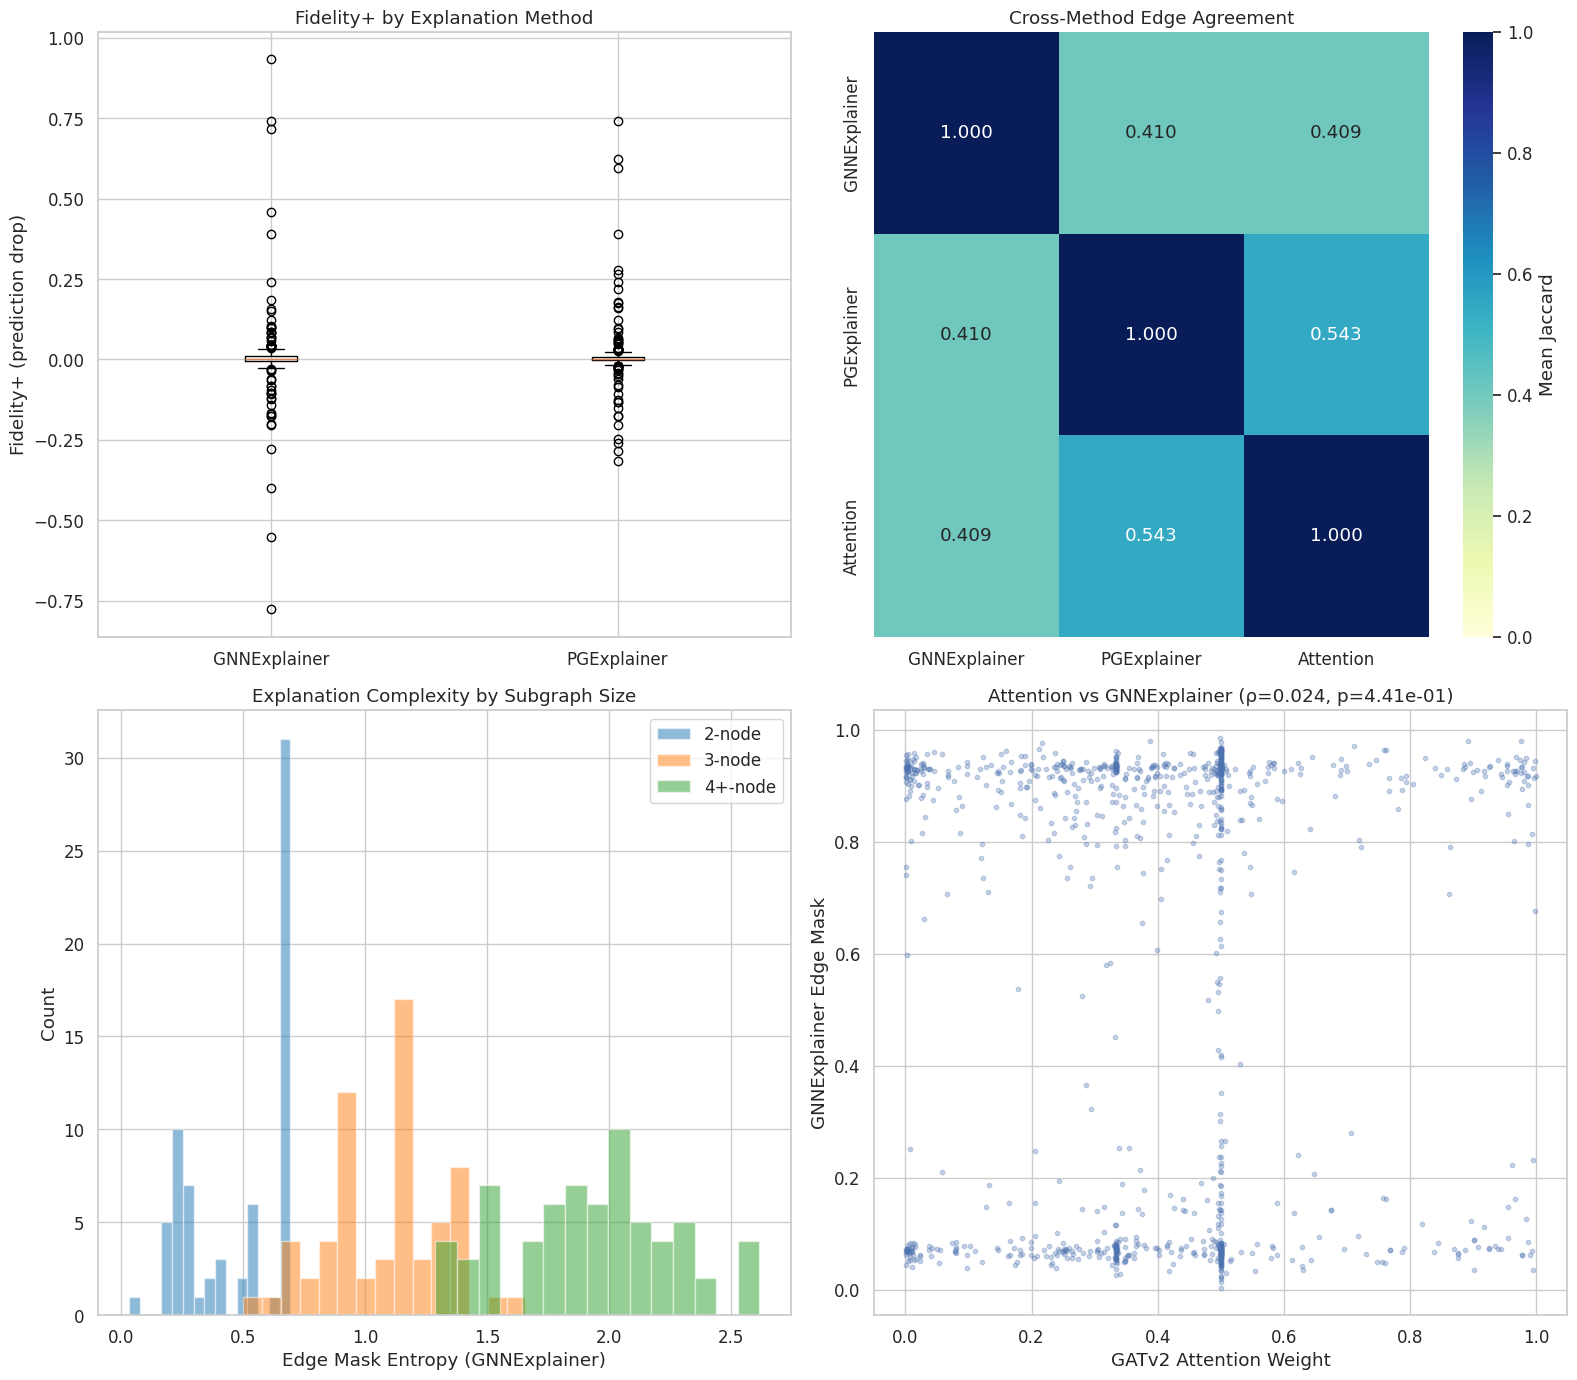

✓ Saved: results/wb06/structural_explanation_analysis.png


In [30]:
# ════════════════════════════════════════════════════════════════
# 3.5d  Comprehensive visualisation
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# (a) Fidelity comparison
ax = axes[0, 0]
fidelity_data = []
if len(fid_gnn_df) > 0:
    fidelity_data.append(("GNNExplainer", fid_gnn_df["fidelity_plus"].values))
if len(fid_pg_df) > 0:
    fidelity_data.append(("PGExplainer", fid_pg_df["fidelity_plus"].values))

if fidelity_data:
    labels, values = zip(*fidelity_data)
    ax.boxplot(values, labels=labels)
    ax.set_ylabel("Fidelity+ (prediction drop)")
    ax.set_title("Fidelity+ by Explanation Method")
else:
    ax.text(0.5, 0.5, "No fidelity data", ha="center", va="center")

# (b) Cross-method agreement heatmap
ax = axes[0, 1]
agreement_matrix = np.zeros((len(methods), len(methods)))
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i == j:
            agreement_matrix[i, j] = 1.0
        elif (m1, m2) in agreement_pairs and agreement_pairs[(m1, m2)]:
            agreement_matrix[i, j] = np.mean(agreement_pairs[(m1, m2)])
            agreement_matrix[j, i] = agreement_matrix[i, j]
        elif (m2, m1) in agreement_pairs and agreement_pairs[(m2, m1)]:
            agreement_matrix[i, j] = np.mean(agreement_pairs[(m2, m1)])
            agreement_matrix[j, i] = agreement_matrix[i, j]

sns.heatmap(agreement_matrix, ax=ax, xticklabels=methods, yticklabels=methods,
            cmap="YlGnBu", annot=True, fmt=".3f", vmin=0, vmax=1,
            cbar_kws={"label": "Mean Jaccard"})
ax.set_title("Cross-Method Edge Agreement")

# (c) Edge mask entropy by subgraph size
ax = axes[1, 0]
for size, color in [("2-node", "tab:blue"), ("3-node", "tab:orange"),
                     ("4+-node", "tab:green")]:
    entropies = [g["edge_mask_entropy"] for g in size_groups.get(size, [])]
    if entropies:
        ax.hist(entropies, bins=15, alpha=0.5, label=size, color=color)
ax.set_xlabel("Edge Mask Entropy (GNNExplainer)")
ax.set_ylabel("Count")
ax.set_title("Explanation Complexity by Subgraph Size")
ax.legend()

# (d) Attention vs GNNExplainer scatter (for shared subgraphs)
ax = axes[1, 1]
scatter_data = {"attn": [], "gnnexp": []}
for idx in sample_indices:
    ccid = int(test_ccids[idx])
    data = test_ds[int(idx)]
    if (ccid in attention_results and ccid in gnnexp_results
            and gnnexp_results[ccid]["edge_mask"] is not None):
        # Use aligned attention (self-loops removed)
        attn_mask = extract_attention_edge_mask(attention_results[ccid], data)
        em = gnnexp_results[ccid]["edge_mask"]
        if attn_mask is not None and len(attn_mask) == len(em):
            scatter_data["attn"].extend(attn_mask.tolist())
            scatter_data["gnnexp"].extend(em.tolist())

if scatter_data["attn"]:
    ax.scatter(scatter_data["attn"], scatter_data["gnnexp"], alpha=0.3, s=10)
    rho, p = sp_stats.spearmanr(scatter_data["attn"], scatter_data["gnnexp"])
    ax.set_xlabel("GATv2 Attention Weight")
    ax.set_ylabel("GNNExplainer Edge Mask")
    ax.set_title(f"Attention vs GNNExplainer (ρ={rho:.3f}, p={p:.2e})")
else:
    ax.text(0.5, 0.5, "No comparable data", ha="center", va="center")

plt.tight_layout()
plt.savefig(WB06_DIR / "structural_explanation_analysis.png", dpi=150,
            bbox_inches="tight")
plt.show()
print(f"✓ Saved: {WB06_DIR / 'structural_explanation_analysis.png'}")

In [31]:
# ════════════════════════════════════════════════════════════════
# 3.6  Save all Tier 2 results
# ════════════════════════════════════════════════════════════════
import pickle

# GNNExplainer results
with open(WB06_DIR / "gnnexplainer_results.pkl", "wb") as f:
    pickle.dump(gnnexp_results, f)

# PGExplainer results
with open(WB06_DIR / "pgexplainer_results.pkl", "wb") as f:
    pickle.dump(pgexp_results, f)

# Attention results
with open(WB06_DIR / "attention_results.pkl", "wb") as f:
    pickle.dump(attention_results, f)

# SubgraphX results
with open(WB06_DIR / "subgraphx_results.pkl", "wb") as f:
    pickle.dump(subgraphx_results, f)

# Fidelity results
if len(fid_gnn_df) > 0:
    fid_gnn_df.to_csv(WB06_DIR / "fidelity_gnnexplainer.csv", index=False)
if len(fid_pg_df) > 0:
    fid_pg_df.to_csv(WB06_DIR / "fidelity_pgexplainer.csv", index=False)

print("✓ All Tier 2 results saved to:", WB06_DIR)
print(f"  gnnexplainer_results.pkl  ({len(gnnexp_results)} subgraphs)")
print(f"  pgexplainer_results.pkl   ({len(pgexp_results)} subgraphs)")
print(f"  attention_results.pkl     ({len(attention_results)} subgraphs)")
print(f"  subgraphx_results.pkl     ({len(subgraphx_results)} subgraphs)")

✓ All Tier 2 results saved to: results/wb06
  gnnexplainer_results.pkl  (200 subgraphs)
  pgexplainer_results.pkl   (200 subgraphs)
  attention_results.pkl     (200 subgraphs)
  subgraphx_results.pkl     (50 subgraphs)


In [1]:
# ════════════════════════════════════════════════════════════════
# 3.7  Final analysis summary
# ════════════════════════════════════════════════════════════════
# Standalone, idempotent. Reads all artefacts from results/,
# auto-detects PG collapse, writes summary JSON and supporting CSVs,
# prints a headline report for immediate inspection.

import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "results" / "wb06").exists():
    REPO_ROOT = REPO_ROOT / "CODE"

P = {
    "test_preds":   REPO_ROOT / "results" / "wb04" / "test_predictions.csv",
    "sample":       REPO_ROOT / "results" / "wb04" / "explanation_sample.csv",
    "ig":           REPO_ROOT / "results" / "wb05" / "ig_subgraph_attributions.npy",
    "shap":         REPO_ROOT / "results" / "wb05" / "shapley_subgraph_attributions.npy",
    "clusters":     REPO_ROOT / "results" / "wb05" / "feature_clusters.npy",
    "gnn":          REPO_ROOT / "results" / "wb06" / "gnnexplainer_results.pkl",
    "pg":           REPO_ROOT / "results" / "wb06" / "pgexplainer_results.pkl",
    "attn":         REPO_ROOT / "results" / "wb06" / "attention_results.pkl",
    "sx":           REPO_ROOT / "results" / "wb06" / "subgraphx_results.pkl",
    "fid_gnn":      REPO_ROOT / "results" / "wb06" / "fidelity_gnnexplainer.csv",
    "fid_pg":       REPO_ROOT / "results" / "wb06" / "fidelity_pgexplainer.csv",
    "out_json":     REPO_ROOT / "results" / "wb04_05_06_analysis_summary_v2.json",
    "out_pairwise": REPO_ROOT / "results" / "wb06" / "cross_method_pairwise.csv",
    "out_fid_quad": REPO_ROOT / "results" / "wb06" / "fidelity_by_quadrant.csv",
    "out_fid_size": REPO_ROOT / "results" / "wb06" / "fidelity_by_size.csv",
}

def _describe(x, n_round=4):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return {"n": 0}
    return {"n": int(x.size),
            "mean": round(float(np.mean(x)), n_round),
            "std":  round(float(np.std(x)),  n_round),
            "min":  round(float(np.min(x)),  n_round),
            "max":  round(float(np.max(x)),  n_round),
            "p25":  round(float(np.percentile(x, 25)), n_round),
            "p50":  round(float(np.percentile(x, 50)), n_round),
            "p75":  round(float(np.percentile(x, 75)), n_round)}

def _top_k_set(mask, k_frac=0.5):
    if mask is None or len(mask) == 0:
        return set()
    k = max(int(round(len(mask) * k_frac)), 1)
    return set(np.argsort(mask)[::-1][:k].astype(int).tolist())

def _jaccard(a, b):
    if not a and not b:
        return 1.0
    u = a | b
    return len(a & b) / len(u) if u else 0.0

def _spearman(a, b):
    try:
        from scipy.stats import spearmanr
        rho, p = spearmanr(a, b)
        return float(rho), float(p)
    except Exception:
        pass
    if a.size < 2 or np.std(a) == 0 or np.std(b) == 0:
        return 0.0, 1.0
    ra = np.argsort(np.argsort(a)); rb = np.argsort(np.argsort(b))
    return float(np.corrcoef(ra, rb)[0, 1]), float("nan")

def _align_attention_to_orig(attn_result, orig_edge_index):
    layer = attn_result.get("layer_attentions")
    if not layer or layer[-1] is None:
        return None
    ei_attn = np.asarray(layer[-1]["edge_index"])
    alpha   = np.asarray(layer[-1]["alpha"])
    if alpha.ndim > 1:
        alpha = alpha.mean(axis=1)
    lookup = {(int(ei_attn[0, e]), int(ei_attn[1, e])): float(alpha[e])
              for e in range(ei_attn.shape[1])}
    return np.asarray(
        [lookup.get((int(orig_edge_index[0, e]), int(orig_edge_index[1, e])), 0.0)
         for e in range(orig_edge_index.shape[1])], dtype=np.float64)

# ── load artefacts ──────────────────────────────────────────────
preds  = pd.read_csv(P["test_preds"])
sample = pd.read_csv(P["sample"])
gnn_res  = pickle.load(open(P["gnn"],  "rb"))
attn_res = pickle.load(open(P["attn"], "rb"))
sx_res   = pickle.load(open(P["sx"],   "rb"))
pg_res   = pickle.load(open(P["pg"],   "rb")) if P["pg"].exists() else None
ig   = np.load(P["ig"])
shap = np.load(P["shap"])
try:
    clusters = np.load(P["clusters"])
except FileNotFoundError:
    clusters = None
fid_gnn = pd.read_csv(P["fid_gnn"])
fid_pg  = pd.read_csv(P["fid_pg"]) if P["fid_pg"].exists() else None

print(f"[summary] loaded  sample={len(sample)}  GNN={len(gnn_res)}  "
      f"attn={len(attn_res)}  SX={len(sx_res)}  PG={len(pg_res) if pg_res else 0}")

# ── PG collapse detection ───────────────────────────────────────
pg_collapse = {"status": "not_loaded"}
if pg_res is not None:
    max_mags, std_mags = [], []
    n_none = n_zero = n_uniform = 0
    for v in pg_res.values():
        m = v.get("edge_mask")
        if m is None:
            n_none += 1; continue
        a = np.asarray(m)
        if a.size == 0:
            continue
        max_mags.append(float(np.abs(a).max()))
        std_mags.append(float(a.std()))
        if np.abs(a).max() < 1e-10:
            n_zero += 1
        elif a.std() < 1e-4:
            n_uniform += 1
    n_eval = len(max_mags)
    collapse_rate = n_zero / max(n_eval, 1)
    uniform_rate  = n_uniform / max(n_eval, 1)
    pg_collapse = {
        "n": n_eval, "n_none": n_none,
        "n_all_zero": n_zero, "n_near_uniform": n_uniform,
        "collapse_rate": round(collapse_rate, 4),
        "uniform_rate":  round(uniform_rate, 4),
        "max_magnitude":    _describe(np.asarray(max_mags)) if max_mags else {},
        "within_graph_std": _describe(np.asarray(std_mags)) if std_mags else {},
        "status": "collapsed" if (collapse_rate + uniform_rate) > 0.9 else "partial",
    }

PG_USABLE = pg_res is not None and pg_collapse.get("status") != "collapsed"

# ── method mask stats ───────────────────────────────────────────
def _mask_stats(d, key="edge_mask"):
    maxes, means, n_none, n_zero = [], [], 0, 0
    for v in d.values():
        m = v.get(key)
        if m is None:
            n_none += 1; continue
        a = np.abs(np.asarray(m, dtype=np.float64))
        if a.size == 0:
            continue
        maxes.append(float(a.max()))
        means.append(float(a.mean()))
        if a.max() < 1e-10:
            n_zero += 1
    if not maxes:
        return {"n_none": n_none, "n_all_zero": n_zero}
    return {"n": len(maxes),
            "max": _describe(np.array(maxes)),
            "mean": _describe(np.array(means)),
            "n_none": n_none, "n_all_zero": n_zero}

method_stats = {
    "gnnexplainer":      _mask_stats(gnn_res),
    "attention_aligned": None,
    "subgraphx":         _mask_stats(sx_res, key="node_importance"),
}
if PG_USABLE:
    method_stats["pgexplainer"] = _mask_stats(pg_res)

# ── near-uniform rate by size bucket ────────────────────────────
def _near_uniform_by_size(d, mask_key="edge_mask"):
    buckets = {"1-edge": [], "2-edge": [], "3+-edge": []}
    for v in d.values():
        m = v.get(mask_key)
        if m is None:
            continue
        arr = np.asarray(m)
        n = len(arr)
        flat = float(np.std(arr)) < 1e-4
        key = "1-edge" if n <= 2 else ("2-edge" if n <= 4 else "3+-edge")
        buckets[key].append(flat)
    return {k: {"n": len(v), "n_flat": int(sum(v)),
                "rate": round(sum(v)/len(v), 4)}
            for k, v in buckets.items() if v}

near_uniform = {"gnnexplainer": _near_uniform_by_size(gnn_res)}
if pg_res is not None:
    near_uniform["pgexplainer"] = _near_uniform_by_size(pg_res)
attn_buckets = {"1-edge": [], "2-edge": [], "3+-edge": []}
for v in attn_res.values():
    layer = v.get("layer_attentions")
    if not layer or layer[-1] is None:
        continue
    ei = np.asarray(layer[-1]["edge_index"])
    alpha = np.asarray(layer[-1]["alpha"])
    if alpha.ndim > 1:
        alpha = alpha.mean(axis=1)
    non_self = ei[0] != ei[1]
    alpha_orig = alpha[non_self]
    if alpha_orig.size == 0:
        continue
    n = len(alpha_orig)
    flat = float(alpha_orig.std()) < 1e-4
    key = "1-edge" if n <= 2 else ("2-edge" if n <= 4 else "3+-edge")
    attn_buckets[key].append(flat)
near_uniform["attention"] = {
    k: {"n": len(v), "n_flat": int(sum(v)),
        "rate": round(sum(v)/len(v), 4) if v else 0.0}
    for k, v in attn_buckets.items() if v}

# ── cross-method pairwise (GNN vs Attn; PG only if usable) ──────
pairwise_records = []
attn_aligned_maxes, attn_aligned_means = [], []
length_match_hits = length_match_total = 0
attn_vs_gnn_spearman = []

for ccid in sample["ccId"].tolist():
    v_attn = attn_res.get(ccid)
    v_gnn  = gnn_res.get(ccid)
    v_pg   = pg_res.get(ccid) if PG_USABLE else None
    if v_attn is None or v_gnn is None:
        continue
    gnn_mask = v_gnn.get("edge_mask")
    if gnn_mask is None or len(gnn_mask) < 2:
        continue
    ei_full = np.asarray(v_attn["layer_attentions"][-1]["edge_index"])
    non_self = ei_full[0] != ei_full[1]
    ei_orig = ei_full[:, non_self]
    length_match_total += 1
    if ei_orig.shape[1] == len(gnn_mask):
        length_match_hits += 1
    attn_on_orig = _align_attention_to_orig(v_attn, ei_orig)
    if attn_on_orig is None or len(attn_on_orig) != len(gnn_mask):
        continue
    attn_aligned_maxes.append(float(np.max(np.abs(attn_on_orig))))
    attn_aligned_means.append(float(np.mean(np.abs(attn_on_orig))))
    if len(gnn_mask) >= 3:
        rho, p = _spearman(np.asarray(gnn_mask, dtype=np.float64), attn_on_orig)
        if not np.isnan(rho):
            attn_vs_gnn_spearman.append({"ccId": int(ccid), "rho": float(rho),
                                         "p": float(p), "n_edges": int(len(gnn_mask))})
    gnn_top  = _top_k_set(np.asarray(gnn_mask))
    attn_top = _top_k_set(attn_on_orig)
    rec = {"ccId": int(ccid), "n_edges": int(len(gnn_mask)),
           "jaccard_gnn_attn": _jaccard(gnn_top, attn_top)}
    if v_pg is not None and v_pg.get("edge_mask") is not None:
        pg_top = _top_k_set(np.asarray(v_pg["edge_mask"]))
        rec["jaccard_gnn_pg"]  = _jaccard(gnn_top, pg_top)
        rec["jaccard_pg_attn"] = _jaccard(pg_top, attn_top)
    pairwise_records.append(rec)

pairwise_df = pd.DataFrame(pairwise_records)
pairwise_df.to_csv(P["out_pairwise"], index=False)

def _agg(col):
    if col not in pairwise_df.columns:
        return {}
    x = pairwise_df[col].dropna().to_numpy()
    return _describe(x) if x.size else {}

cross_method = {
    "pg_excluded_reason":  (pg_collapse.get("status") if not PG_USABLE else None),
    "n_pairs":             int(len(pairwise_df)),
    "jaccard_gnn_attn":    _agg("jaccard_gnn_attn"),
    "length_match_rate":   round(length_match_hits / max(length_match_total, 1), 4),
    "length_match_hits":   int(length_match_hits),
    "length_match_total":  int(length_match_total),
    "attn_vs_gnn_per_edge_spearman": _describe(
        np.array([r["rho"] for r in attn_vs_gnn_spearman])
    ) if attn_vs_gnn_spearman else {},
}
if PG_USABLE:
    cross_method["jaccard_gnn_pg"]  = _agg("jaccard_gnn_pg")
    cross_method["jaccard_pg_attn"] = _agg("jaccard_pg_attn")

method_stats["attention_aligned"] = {
    "n":    len(attn_aligned_maxes),
    "max":  _describe(np.asarray(attn_aligned_maxes)),
    "mean": _describe(np.asarray(attn_aligned_means)),
}

# ── stratified Jaccard by size bucket ───────────────────────────
if not pairwise_df.empty:
    def _bucket(n):
        return "1-edge" if n <= 2 else ("2-edge" if n <= 4 else "3+-edge")
    pairwise_df["size_bucket"] = pairwise_df["n_edges"].apply(_bucket)
    jaccard_by_size = pairwise_df.groupby("size_bucket").agg(
        n=("jaccard_gnn_attn", "size"),
        j_gnn_attn_mean=("jaccard_gnn_attn", "mean"),
        j_gnn_attn_std=("jaccard_gnn_attn",  "std"),
    ).round(4).reset_index().to_dict(orient="records")
else:
    jaccard_by_size = []

# ── fidelity ────────────────────────────────────────────────────
labels_df = sample[["ccId", "quadrant", "size_bucket"]]
fid_outputs, fid_quad_frames, fid_size_frames = {}, [], []

def _fid_block(name, df):
    joined = df.merge(labels_df, on="ccId", how="inner")
    by_size = joined.groupby("size_bucket").agg(
        n=("fidelity_plus", "size"),
        fid_plus_mean=("fidelity_plus", "mean"),
        fid_plus_std =("fidelity_plus", "std"),
        fid_minus_mean=("fidelity_minus", "mean"),
        fid_minus_std =("fidelity_minus", "std"),
    ).reset_index()
    by_size["method"] = name
    by_quad = joined.groupby("quadrant").agg(
        n=("fidelity_plus", "size"),
        fid_plus_mean=("fidelity_plus", "mean"),
        fid_plus_std =("fidelity_plus", "std"),
        fid_minus_mean=("fidelity_minus", "mean"),
        fid_minus_std =("fidelity_minus", "std"),
    ).reset_index()
    by_quad["method"] = name
    return by_size, by_quad, {
        "overall": {
            "n":              int(len(joined)),
            "fid_plus_mean":  round(float(joined.fidelity_plus.mean()), 4),
            "fid_plus_std":   round(float(joined.fidelity_plus.std()),  4),
            "fid_minus_mean": round(float(joined.fidelity_minus.mean()),4),
            "fid_minus_std":  round(float(joined.fidelity_minus.std()), 4),
        },
        "by_size":     by_size.round(4).to_dict(orient="records"),
        "by_quadrant": by_quad.round(4).to_dict(orient="records"),
    }

_s, _q, fid_outputs["gnnexplainer"] = _fid_block("gnnexplainer", fid_gnn)
fid_size_frames.append(_s); fid_quad_frames.append(_q)

if PG_USABLE and fid_pg is not None:
    _s, _q, fid_outputs["pgexplainer"] = _fid_block("pgexplainer", fid_pg)
    fid_size_frames.append(_s); fid_quad_frames.append(_q)
elif fid_pg is not None:
    fid_outputs["pgexplainer"] = {
        "excluded": True,
        "reason": "mask collapse - fidelity values computed on zero masks are not interpretable",
    }

if fid_size_frames:
    pd.concat(fid_size_frames, ignore_index=True).to_csv(P["out_fid_size"], index=False)
if fid_quad_frames:
    pd.concat(fid_quad_frames, ignore_index=True).to_csv(P["out_fid_quad"], index=False)

# ── feature attribution ─────────────────────────────────────────
assert ig.shape[0] == len(sample) and shap.shape[0] == len(sample)
y = sample["y_true"].to_numpy()
yhat = sample["y_pred"].to_numpy()

def _signed_diff(attr):
    suspicious = attr[y == 1].mean(axis=0)
    licit      = attr[y == 0].mean(axis=0)
    diff = suspicious - licit
    order = np.argsort(np.abs(diff))[::-1]
    return [{"feature": f"F{int(i)}",
             "signed_diff": round(float(diff[i]), 4),
             "mean_suspicious": round(float(suspicious[i]), 4),
             "mean_licit":      round(float(licit[i]),      4)}
            for i in order[:20]]

def _tp_top5(attr):
    tp_mask = (y == 1) & (yhat == 1)
    tp_attr = np.abs(attr[tp_mask])
    if tp_attr.shape[0] == 0:
        return []
    top5 = np.argsort(tp_attr, axis=1)[:, ::-1][:, :5]
    counts = np.bincount(top5.ravel(), minlength=attr.shape[1])
    order = np.argsort(counts)[::-1]
    total_tp = int(tp_mask.sum())
    return [{"feature": f"F{int(i)}",
             "tp_count": int(counts[i]),
             "tp_frac":  round(float(counts[i] / total_tp), 3)}
            for i in order[:10] if counts[i] > 0]

ig_abs_mean   = np.abs(ig).mean(axis=0)
shap_abs_mean = np.abs(shap).mean(axis=0)
rho_global, _ = _spearman(ig_abs_mean, shap_abs_mean)
per_sample_rhos = []
for i in range(ig.shape[0]):
    rho, _ = _spearman(np.abs(ig[i]), np.abs(shap[i]))
    if not np.isnan(rho):
        per_sample_rhos.append(float(rho))

# ── GNN entropy by size ─────────────────────────────────────────
entropy_by_size = {"2-node": [], "3-node": [], "4+-node": []}
for _, row in sample.iterrows():
    ccid = int(row["ccId"])
    size = row["size_bucket"]
    v = gnn_res.get(ccid)
    if v is None or v.get("edge_mask") is None:
        continue
    em = np.asarray(v["edge_mask"], dtype=np.float64)
    em_norm = em / (em.sum() + 1e-10)
    H = float(-np.sum(em_norm * np.log(em_norm + 1e-10)))
    entropy_by_size[size].append(H)

gnn_by_size = {s: {"n": len(vals),
                   "entropy_mean": round(float(np.mean(vals)), 4),
                   "entropy_std":  round(float(np.std(vals)),  4)}
               for s, vals in entropy_by_size.items() if vals}

# ── SubgraphX summary ───────────────────────────────────────────
sx_n_nodes, sx_n_expl, sx_ratio = [], [], []
for v in sx_res.values():
    sx_n_nodes.append(int(v.get("n_nodes", 0)))
    sx_n_expl.append(int(v.get("n_explanation_nodes", 0)))
    if v.get("n_nodes"):
        sx_ratio.append(v["n_explanation_nodes"] / v["n_nodes"])

subgraphx_summary = {"n": len(sx_res),
                     "n_nodes":      _describe(np.asarray(sx_n_nodes)),
                     "n_expl_nodes": _describe(np.asarray(sx_n_expl)),
                     "expl_ratio":   _describe(np.asarray(sx_ratio))}

# ── primary model ───────────────────────────────────────────────
thr = float(sample.loc[sample["y_pred"] == 1, "prob"].min())
y_true_full = preds["y_true"].to_numpy()
probs_full  = preds["prob_suspicious"].to_numpy()
yhat_full   = (probs_full >= thr).astype(int)
TP = int(((y_true_full == 1) & (yhat_full == 1)).sum())
FP = int(((y_true_full == 0) & (yhat_full == 1)).sum())
FN = int(((y_true_full == 1) & (yhat_full == 0)).sum())
TN = int(((y_true_full == 0) & (yhat_full == 0)).sum())
primary = {"threshold": round(thr, 4),
           "confusion": {"TP": TP, "FP": FP, "FN": FN, "TN": TN},
           "n_test": int(len(preds)),
           "prevalence": round(float(y_true_full.mean()), 4),
           "precision_at_thr": round(TP / max(TP + FP, 1), 4),
           "recall_at_thr":    round(TP / max(TP + FN, 1), 4),
           "f1_at_thr":        round(2 * TP / max(2 * TP + FP + FN, 1), 4)}

# ── assemble and write ──────────────────────────────────────────
out = {
    "primary_model":            primary,
    "pg_collapse":              pg_collapse,
    "pg_usable":                PG_USABLE,
    "method_mask_stats":        method_stats,
    "near_uniform_by_size":     near_uniform,
    "cross_method":             cross_method,
    "jaccard_gnn_attn_by_size": jaccard_by_size,
    "fidelity":                 fid_outputs,
    "feature_attribution": {
        "ig_top20_signed_diff":      _signed_diff(ig),
        "shapley_top20_signed_diff": _signed_diff(shap),
        "ig_tp_top5_frequency":      _tp_top5(ig),
        "shap_tp_top5_frequency":    _tp_top5(shap),
        "ig_vs_shap_rank_agreement": {
            "global_abs_mean_spearman": round(rho_global, 4),
            "per_sample_spearman":      _describe(np.asarray(per_sample_rhos)),
        },
    },
    "gnn_entropy_by_size": gnn_by_size,
    "subgraphx":           subgraphx_summary,
    "clusters_shape":      None if clusters is None else list(clusters.shape),
}

with open(P["out_json"], "w") as f:
    json.dump(out, f, indent=2)

# ── headline print ──────────────────────────────────────────────
print()
print("=" * 66)
print("FINAL ANALYSIS SUMMARY")
print("=" * 66)
print(f"Primary model:  TP={TP}  FP={FP}  FN={FN}  TN={TN}")
print(f"                thr={thr:.4f}  F1={primary['f1_at_thr']}  "
      f"prec={primary['precision_at_thr']}  rec={primary['recall_at_thr']}")
print()
print(f"PG status: {pg_collapse.get('status')}  "
      f"(collapse_rate={pg_collapse.get('collapse_rate', 'n/a')}, "
      f"uniform_rate={pg_collapse.get('uniform_rate', 'n/a')})")
print(f"→ PG is {'INCLUDED' if PG_USABLE else 'EXCLUDED'} from cross-method comparisons")
print()
print("Near-uniform rate by size (lower = more discriminative):")
for method, buckets in near_uniform.items():
    row = f"  {method.ljust(14)}"
    for size in ["1-edge", "2-edge", "3+-edge"]:
        if size in buckets:
            b = buckets[size]
            row += f"  {size}: {b['n_flat']}/{b['n']} ({100*b['rate']:.0f}%)"
    print(row)
print()
print("Cross-method Jaccard (top-50% edges):")
print(f"  GNN vs Attention:  {cross_method['jaccard_gnn_attn'].get('mean', 'n/a')}  "
      f"(n={cross_method['n_pairs']})")
if jaccard_by_size:
    print("  by subgraph size:")
    for r in jaccard_by_size:
        print(f"    {r['size_bucket']}: mean={r['j_gnn_attn_mean']} "
              f"± {r['j_gnn_attn_std']}  (n={r['n']})")
print()
if "gnnexplainer" in fid_outputs and "overall" in fid_outputs["gnnexplainer"]:
    o = fid_outputs["gnnexplainer"]["overall"]
    print(f"Fidelity+ (GNN):   {o['fid_plus_mean']} ± {o['fid_plus_std']}")
    print(f"Fidelity- (GNN):   {o['fid_minus_mean']} ± {o['fid_minus_std']}")
print()
print("IG  top-5 signed diff:  " + "  ".join(
    [f"{r['feature']}({r['signed_diff']:+.3f})"
     for r in out['feature_attribution']['ig_top20_signed_diff'][:5]]))
print("SHP top-5 signed diff:  " + "  ".join(
    [f"{r['feature']}({r['signed_diff']:+.3f})"
     for r in out['feature_attribution']['shapley_top20_signed_diff'][:5]]))
print(f"IG vs SHP rank agreement (global abs-mean): ρ={rho_global:.4f}")
print()
print("GNN entropy by size:  " + "  ".join(
    [f"{s}: {d['entropy_mean']}" for s, d in gnn_by_size.items()]))
print(f"SubgraphX: n={subgraphx_summary['n']}, "
      f"median nodes kept {subgraphx_summary['n_expl_nodes']['p50']}/"
      f"{subgraphx_summary['n_nodes']['p50']} "
      f"(ratio {subgraphx_summary['expl_ratio']['mean']})")
print()
print(f"✓ summary written to {P['out_json']}")
print(f"✓ CSVs written to    {P['out_pairwise'].parent}")

[summary] loaded  sample=200  GNN=200  attn=200  SX=50  PG=200

FINAL ANALYSIS SUMMARY
Primary model:  TP=236  FP=127  FN=317  TN=23682
                thr=0.9136  F1=0.5153  prec=0.6501  rec=0.4268

PG status: collapsed  (collapse_rate=1.0, uniform_rate=0.0)
→ PG is EXCLUDED from cross-method comparisons

Near-uniform rate by size (lower = more discriminative):
  gnnexplainer    1-edge: 0/69 (0%)  2-edge: 0/61 (0%)  3+-edge: 0/70 (0%)
  pgexplainer     1-edge: 69/69 (100%)  2-edge: 61/61 (100%)  3+-edge: 70/70 (100%)
  attention       1-edge: 46/69 (67%)  2-edge: 0/61 (0%)  3+-edge: 1/70 (1%)

Cross-method Jaccard (top-50% edges):
  GNN vs Attention:  0.4086  (n=200)
  by subgraph size:
    1-edge: mean=0.4638 ± 0.5023  (n=69)
    2-edge: mean=0.4044 ± 0.3227  (n=61)
    3+-edge: mean=0.358 ± 0.1689  (n=70)

Fidelity+ (GNN):   0.0066 ± 0.1422
Fidelity- (GNN):   0.0195 ± 0.1391

IG  top-5 signed diff:  F19(-0.349)  F23(-0.134)  F27(+0.132)  F4(-0.104)  F17(-0.080)
SHP top-5 signed diff

C:\Users\neric\AppData\Local\Temp\ipykernel_6772\3426661929.py:63: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(a, b)
